In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
# import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn import preprocessing 
# from category_encoders import *
from sklearn.preprocessing import LabelEncoder
%matplotlib inline

from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, f1_score, precision_score
from sklearn.model_selection import RandomizedSearchCV

from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
import lightgbm as lgb
from sklearn import datasets, linear_model, metrics
from sklearn.metrics import  confusion_matrix,roc_auc_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.ensemble import BaggingClassifier
from mlxtend.classifier import StackingClassifier
from sklearn.datasets import make_classification
import warnings
warnings.filterwarnings("ignore")

In [2]:
data=pd.read_csv('../clean-data.csv')
data=data.drop(['Unnamed: 0'],axis=1)
X_yuan=data.drop(['Group'],axis=1)
y_yuan=data['Group']

In [3]:
df=data
col=df.columns
df = df.dropna()
df = df.drop_duplicates()
from sklearn.neighbors import LocalOutlierFactor
lof = LocalOutlierFactor(n_neighbors=10, contamination=0.01)  # contamination 为异常值比例
lof_predictions = lof.fit_predict(df)
# 将预测结果添加到 DataFrame 中
df['LOF_Predictions'] = lof_predictions
# 筛选出离群值（预测结果为 -1 的点）
outliers = df[df['LOF_Predictions'] == -1]
print("离群值：")
print(outliers)
# 删除离群值所在的行
df_cleaned = df[df['LOF_Predictions'] == 1]  # 保留正常值
df_cleaned = df_cleaned.drop(columns=['LOF_Predictions'])  # 删除辅助列
print("删除离群值后的数据：")
print(df_cleaned)
X=df_cleaned.drop(['Group'],axis=1)
y=df_cleaned['Group']

离群值：
     Group  Age  Gender  APG_0101010001P  APG_0101010002M  APG_0101010006P  \
0        0   63       1             0.37             0.06             2.44   
108      1   63       0             3.43             0.32             1.71   

     APG_0101010009P  APG_0101010010M  APG_0101010012P  APG_0101010014M  ...  \
0               2.09             0.05             0.00            15.76  ...   
108             4.72             0.54             0.44            13.41  ...   

     APG_0101010364P  APG_0101010365P  APG_0101020006P  APG_0101020009M  \
0            3606.19            54.99             9.42             3.97   
108           518.79           164.37             2.88             3.47   

     APG_0101020013M  APG_0101020024P  APG_0101020027M  APG_0101020028P  \
0               0.37             2.26             0.81             1.26   
108             0.40             1.13             2.89             0.53   

     APG_0101020029M  LOF_Predictions  
0              66.17       

In [4]:
column=X.columns
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_pre=sc.fit_transform(X)
X_pre=pd.DataFrame(data=X_pre,columns=column)

In [5]:
X_train,X_test,y_train,y_test = train_test_split(X_pre,y,test_size=0.2,random_state=50,stratify=None)
print(f'Train shape : {X_train.shape}\nTest shape: {X_test.shape}')

Train shape : (130, 203)
Test shape: (33, 203)


### 定义函数

In [1]:
def crosspredict(estimator,Xtrain,ytrain,cv):
    print("cross-validate across the entire data set")
    y_pred_cross=cross_val_predict(estimator,Xtrain,ytrain,cv=cv)
    confusion_cross=confusion_matrix(ytrain,y_pred_cross)
    a=accuracy_score(ytrain,y_pred_cross)
    p=precision_score(ytrain, y_pred_cross)
    r=recall_score(ytrain, y_pred_cross)
    f1=f1_score(ytrain, y_pred_cross)
    wf1=f1_score(ytrain, y_pred_cross, average='weighted')
    print('the confusion_matrix of the model is : \n',confusion_cross)
    print('the accuracy of the model is : ',a)
    print("the precision score of the model is : ", p)
    print("the recall score of the model is :", r)
    print('the f1_score of the model  is :',f1)
    print('the weighted_f1 of the model is :',wf1)
    print('the classification_report is :\n',classification_report(ytrain, y_pred_cross,digits=4))
    return a,p,r,f1,wf1,y_pred_cross,ytrain
def crosspredict_proba(estimator,Xtrain,ytrain,cv):
    print("cross-validate across the entire data set")
    y_pred_proba=cross_val_predict(estimator,Xtrain,ytrain,cv=cv,method='predict_proba')
    return y_pred_proba 

### 搭建模型

In [6]:


clf1=SVC(C=1, coef0=10, degree=4, kernel='poly', probability=True)
clf2=KNeighborsClassifier(n_neighbors=3, p=1)
clf3=LogisticRegression(C=0.1)
clf4=GaussianNB()
clf5=BernoulliNB()
clf6=DecisionTreeClassifier(max_depth=5, min_samples_leaf=2, min_samples_split=6)
clf7=RandomForestClassifier(max_depth=8, n_estimators=105, n_jobs=-1,random_state=90)
clf8=AdaBoostClassifier(learning_rate=0.1)
clf9=GradientBoostingClassifier(loss='exponential', n_estimators=300)
clf10=XGBClassifier(booster='gblinear',learning_rate=0.3,n_estimators=10)
clf11=lgb.LGBMClassifier(max_depth=3, n_estimators=300)
yuan1=SVC(probability=True)
yuan2=KNeighborsClassifier()
yuan3=LogisticRegression()
yuan4=GaussianNB()
yuan6=DecisionTreeClassifier()
yuan7=RandomForestClassifier(random_state=6)
yuan8=AdaBoostClassifier()
yuan9=GradientBoostingClassifier()
yuan10=XGBClassifier()
yuan11=lgb.LGBMClassifier()
from sklearn.base import ClassifierMixin
from sklearn.base import TransformerMixin, BaseEstimator
class MyEstimator(BaseEstimator, ClassifierMixin):
    def __init__(self, model, mask) -> None:
        super().__init__()
        self.mask = mask
        self.model = model
    
    def fit(self, X, y=None):
        self.model.fit(X[self.mask],y)
        self.classes_ = self.model.classes_
        return self

    def predict(self, X):
        return self.model.predict(X[self.mask])
    
    def predict_proba(self,X):
        return self.model.predict_proba(X[self.mask])
sel_seq_dt_mask=['APG_0101010010M','APG_0101010055P','APG_0101010063M','APG_0101010341M','APG_0101010354P']
sel_seq_rf_mask=['APG_0101010055P','APG_0101010262P','APG_0101010266P']
sel_seq_ada_mask=['APG_0101010033M','APG_0101010063M','APG_0101010067M','APG_0101010147M','APG_0101010192M', 'APG_0101010236M']
sel_seq_gb_mask=['APG_0101010002M','APG_0101010055P','APG_0101010266P','APG_0101010354P']
sel_seq_xgb_mask=['APG_0101010010M','APG_0101010037P','APG_0101010063M','APG_0101010078P','APG_0101010150P','APG_0101010230P','APG_0101010279P','APG_0101010312P','APG_0101020013M']
sel_seq_KN_mask=['APG_0101010002M', 'APG_0101010010M', 'APG_0101010052M','APG_0101010055P', 'APG_0101010176P']
sel_seq_Lightgbm_mask=['APG_0101010036M','APG_0101010078P','APG_0101010130P','APG_0101010192M','APG_0101010226P','APG_0101010242P','APG_0101010265P']
sel_seq_SVC_mask=['APG_0101010002M', 'APG_0101010010M', 'APG_0101010037P', 'APG_0101010039M', 'APG_0101010055P', 'APG_0101010143P', 'APG_0101010247P', 'APG_0101010300P', 'APG_0101010332P']
sel_seq_GNB_mask=['APG_0101010010M','APG_0101010055P','APG_0101010057M','APG_0101010081M','APG_0101010085P','APG_0101010199P','APG_0101010264P','APG_0101010279P', 'APG_0101010300P']
sel_seq_lr_mask=['APG_0101010010M','APG_0101010030M','APG_0101010041M','APG_0101010043P','APG_0101010137P','APG_0101010150P','APG_0101010152M','APG_0101010168P','APG_0101010176P','APG_0101010356P']

model_dt_fs = MyEstimator(DecisionTreeClassifier(max_depth=5, min_samples_leaf=2, min_samples_split=6), sel_seq_dt_mask)
model_rf_fs = MyEstimator(RandomForestClassifier(max_depth=8, n_estimators=105, n_jobs=-1,random_state=90), sel_seq_rf_mask)
model_ada_fs = MyEstimator(AdaBoostClassifier(learning_rate=0.1), sel_seq_ada_mask)
model_gb_fs = MyEstimator(GradientBoostingClassifier(loss='exponential', n_estimators=300), sel_seq_gb_mask)
model_xgb_fs = MyEstimator(XGBClassifier(booster='gblinear',learning_rate=0.3,n_estimators=10), mask=sel_seq_xgb_mask)
model_KN_fs = MyEstimator(KNeighborsClassifier(n_neighbors=3, p=1), mask=sel_seq_KN_mask)
model_Lightgbm_fs = MyEstimator(lgb.LGBMClassifier(max_depth=3, n_estimators=300), mask=sel_seq_Lightgbm_mask)
model_SVC_fs = MyEstimator(SVC(C=1, coef0=10, degree=4, kernel='poly', probability=True),mask=sel_seq_SVC_mask)
model_GNB_fs = MyEstimator(GaussianNB(),mask=sel_seq_GNB_mask)
model_lr_fs = MyEstimator(LogisticRegression(C=0.1),mask=sel_seq_lr_mask)

In [7]:
from itertools import *
feature=list(set(sel_seq_dt_mask+sel_seq_rf_mask+sel_seq_ada_mask+sel_seq_GNB_mask+sel_seq_xgb_mask))
model_dt_fs = MyEstimator(DecisionTreeClassifier(max_depth=5, min_samples_leaf=2, min_samples_split=6), sel_seq_dt_mask)
model_rf_fs = MyEstimator(RandomForestClassifier(max_depth=8, n_estimators=105, n_jobs=-1,random_state=90), sel_seq_rf_mask)
model_ada_fs = MyEstimator(AdaBoostClassifier(learning_rate=0.1), sel_seq_ada_mask)
model_xgb_fs = MyEstimator(XGBClassifier(booster='gblinear',learning_rate=0.3,n_estimators=10), mask=sel_seq_xgb_mask)
model_gnb_fs=MyEstimator(GaussianNB(),mask=sel_seq_GNB_mask)
from sklearn.ensemble import VotingClassifier
model_voting_hard = VotingClassifier([
    ("dt",model_dt_fs),
    ("rf",model_rf_fs),
    ("ada", model_ada_fs),
    ("xgb", model_xgb_fs),
    ("gnb",model_gnb_fs),
], voting="hard")

In [8]:
from sklearn.ensemble import StackingClassifier
model_Stacking_cross = StackingClassifier(estimators=[
    ("dt", model_dt_fs),
    ("rf", model_rf_fs),
    ("ada", model_ada_fs),
    ("gnb", model_gnb_fs),
    ("xgb", model_xgb_fs),
], final_estimator=LogisticRegression(C=0.1))

### 计算准确率、精度、召回率、F1、AUC

In [9]:
from sklearn.metrics import roc_auc_score
from scipy import stats
import numpy as np
import pandas as pd
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 初始化 DataFrame
df_acc = pd.DataFrame(columns=['Model', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10'])
df_pre = pd.DataFrame(columns=['Model', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10'])
df_rec = pd.DataFrame(columns=['Model', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10'])
df_f1 = pd.DataFrame(columns=['Model', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10'])
df_auc = pd.DataFrame(columns=['Model', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10'])

# 模型名称
yuanname = ['SVC', 'KNN', 'LR', 'GNB', 'DT', 'RF', 'Ada', 'GBDT', 'XGB', 'LGB']
listname = ['SVC+', 'KNN+', 'LR+', 'GNB+', 'DT+', 'RF+', 'Ada+', 'GBDT+', 'XGB+', 'LGB+']

# 模型列表
modellist = [model_SVC_fs, model_KN_fs, model_lr_fs, model_GNB_fs, model_dt_fs, model_rf_fs, model_ada_fs, model_gb_fs, model_xgb_fs, model_Lightgbm_fs]
modelyuan = [yuan1, yuan2, yuan3, yuan4, yuan6, yuan7, yuan8, yuan9, yuan10, yuan11]

for j in range(10):
    # 原始模型
    predictions = cross_val_predict(modelyuan[j], X_yuan, y_yuan, cv=10)
    predictions_proba = cross_val_predict(modelyuan[j], X_yuan, y_yuan, cv=10, method='predict_proba')
    overall_accuracy = accuracy_score(y_yuan, predictions)
    overall_precision = precision_score(y_yuan, predictions)
    overall_recall = recall_score(y_yuan, predictions)
    overall_f1 = f1_score(y_yuan, predictions)
    overall_auc = roc_auc_score(y_yuan, predictions_proba[:, 1])  # 计算整体 AUC

    fold_accuracies = []
    fold_precisions = []
    fold_recalls = []
    fold_f1s = []
    fold_aucs = []

    for i in range(10):
        test_index = (np.arange(len(y_yuan)) % 10 == i)
        y_true = y_yuan[test_index]
        y_pred = predictions[test_index]
        y_pred_proba = predictions_proba[test_index][:, 1]  # 假设是二分类问题，取正类的概率
        fold_accuracy = accuracy_score(y_true, y_pred)
        fold_precision = precision_score(y_true, y_pred)
        fold_recall = recall_score(y_true, y_pred)
        fold_f1 = f1_score(y_true, y_pred)
        fold_auc = roc_auc_score(y_true, y_pred_proba)  # 计算每一折的 AUC
        fold_accuracies.append(fold_accuracy)
        fold_precisions.append(fold_precision)
        fold_recalls.append(fold_recall)
        fold_f1s.append(fold_f1)
        fold_aucs.append(fold_auc)

    print(yuanname[j])
    print("acc-mean:", overall_accuracy)
    print("pre-mean:", overall_precision)
    print("rec-mean:", overall_recall)
    print("f1-mean:", overall_f1)
    print("auc-mean:", overall_auc)  
    df_acc = df_acc.append({'Model': yuanname[j], '1': fold_accuracies[0], '2': fold_accuracies[1], '3': fold_accuracies[2], '4': fold_accuracies[3],
                            '5': fold_accuracies[4], '6': fold_accuracies[5], '7': fold_accuracies[6], '8': fold_accuracies[7],
                            '9': fold_accuracies[8], '10': fold_accuracies[9]}, ignore_index=True)
    df_pre = df_pre.append({'Model': yuanname[j], '1': fold_precisions[0], '2': fold_precisions[1], '3': fold_precisions[2], '4': fold_precisions[3],
                            '5': fold_precisions[4], '6': fold_precisions[5], '7': fold_precisions[6], '8': fold_precisions[7],
                            '9': fold_precisions[8], '10': fold_precisions[9]}, ignore_index=True)
    df_rec = df_rec.append({'Model': yuanname[j], '1': fold_recalls[0], '2': fold_recalls[1], '3': fold_recalls[2], '4': fold_recalls[3],
                            '5': fold_recalls[4], '6': fold_recalls[5], '7': fold_recalls[6], '8': fold_recalls[7],
                            '9': fold_recalls[8], '10': fold_recalls[9]}, ignore_index=True)
    df_f1 = df_f1.append({'Model': yuanname[j], '1': fold_f1s[0], '2': fold_f1s[1], '3': fold_f1s[2], '4': fold_f1s[3],
                          '5': fold_f1s[4], '6': fold_f1s[5], '7': fold_f1s[6], '8': fold_f1s[7],
                          '9': fold_f1s[8], '10': fold_f1s[9]}, ignore_index=True)
    df_auc = df_auc.append({'Model': yuanname[j], '1': fold_aucs[0], '2': fold_aucs[1], '3': fold_aucs[2], '4': fold_aucs[3],
                            '5': fold_aucs[4], '6': fold_aucs[5], '7': fold_aucs[6], '8': fold_aucs[7],
                            '9': fold_aucs[8], '10': fold_aucs[9]}, ignore_index=True)

    # 改进模型
    predictions = cross_val_predict(modellist[j], X_pre, y, cv=10)
    predictions_proba = cross_val_predict(modellist[j], X_pre, y, cv=10, method='predict_proba')
    overall_accuracy = accuracy_score(y, predictions)
    overall_precision = precision_score(y, predictions)
    overall_recall = recall_score(y, predictions)
    overall_f1 = f1_score(y, predictions)
    overall_auc = roc_auc_score(y, predictions_proba[:, 1])  # 计算整体 AUC

    fold_accuracies = []
    fold_precisions = []
    fold_recalls = []
    fold_f1s = []
    fold_aucs = []

    for i in range(10):
        test_index = (np.arange(len(y)) % 10 == i)
        y_true = y[test_index]
        y_pred = predictions[test_index]
        y_pred_proba = predictions_proba[test_index][:, 1]  # 假设是二分类问题，取正类的概率
        fold_accuracy = accuracy_score(y_true, y_pred)
        fold_precision = precision_score(y_true, y_pred)
        fold_recall = recall_score(y_true, y_pred)
        fold_f1 = f1_score(y_true, y_pred)
        fold_auc = roc_auc_score(y_true, y_pred_proba)  # 计算每一折的 AUC
        fold_accuracies.append(fold_accuracy)
        fold_precisions.append(fold_precision)
        fold_recalls.append(fold_recall)
        fold_f1s.append(fold_f1)
        fold_aucs.append(fold_auc)

    print(listname[j])
    print("acc-mean:", overall_accuracy)
    print("pre-mean:", overall_precision)
    print("rec-mean:", overall_recall)
    print("f1-mean:", overall_f1)
    print("auc-mean:", overall_auc) 
    df_acc = df_acc.append({'Model': listname[j], '1': fold_accuracies[0], '2': fold_accuracies[1], '3': fold_accuracies[2], '4': fold_accuracies[3],
                            '5': fold_accuracies[4], '6': fold_accuracies[5], '7': fold_accuracies[6], '8': fold_accuracies[7],
                            '9': fold_accuracies[8], '10': fold_accuracies[9]}, ignore_index=True)
    df_pre = df_pre.append({'Model': listname[j], '1': fold_precisions[0], '2': fold_precisions[1], '3': fold_precisions[2], '4': fold_precisions[3],
                            '5': fold_precisions[4], '6': fold_precisions[5], '7': fold_precisions[6], '8': fold_precisions[7],
                            '9': fold_precisions[8], '10': fold_precisions[9]}, ignore_index=True)
    df_rec = df_rec.append({'Model': listname[j], '1': fold_recalls[0], '2': fold_recalls[1], '3': fold_recalls[2], '4': fold_recalls[3],
                            '5': fold_recalls[4], '6': fold_recalls[5], '7': fold_recalls[6], '8': fold_recalls[7],
                            '9': fold_recalls[8], '10': fold_recalls[9]}, ignore_index=True)
    df_f1 = df_f1.append({'Model': listname[j], '1': fold_f1s[0], '2': fold_f1s[1], '3': fold_f1s[2], '4': fold_f1s[3],
                          '5': fold_f1s[4], '6': fold_f1s[5], '7': fold_f1s[6], '8': fold_f1s[7],
                          '9': fold_f1s[8], '10': fold_f1s[9]}, ignore_index=True)
    df_auc = df_auc.append({'Model': listname[j], '1': fold_aucs[0], '2': fold_aucs[1], '3': fold_aucs[2], '4': fold_aucs[3],
                            '5': fold_aucs[4], '6': fold_aucs[5], '7': fold_aucs[6], '8': fold_aucs[7],
                            '9': fold_aucs[8], '10': fold_aucs[9]}, ignore_index=True)

SVC
acc-mean: 0.6484848484848484
pre-mean: 0.7543859649122807
rec-mean: 0.4942528735632184
f1-mean: 0.5972222222222222
auc-mean: 0.6987916298261125
SVC+
acc-mean: 0.803680981595092
pre-mean: 0.8857142857142857
rec-mean: 0.7209302325581395
f1-mean: 0.7948717948717948
auc-mean: 0.8193144065237088
KNN
acc-mean: 0.6424242424242425
pre-mean: 0.675
rec-mean: 0.6206896551724138
f1-mean: 0.6467065868263473
auc-mean: 0.676392572944297
KNN+
acc-mean: 0.7668711656441718
pre-mean: 0.8529411764705882
rec-mean: 0.6744186046511628
f1-mean: 0.7532467532467532
auc-mean: 0.7918302627604954
LR
acc-mean: 0.6303030303030303
pre-mean: 0.6444444444444445
rec-mean: 0.6666666666666666
f1-mean: 0.6553672316384181
auc-mean: 0.6702033598585323
LR+
acc-mean: 0.7423312883435583
pre-mean: 0.7619047619047619
rec-mean: 0.7441860465116279
f1-mean: 0.7529411764705882
auc-mean: 0.7343702808819087
GNB
acc-mean: 0.6484848484848484
pre-mean: 0.7377049180327869
rec-mean: 0.5172413793103449
f1-mean: 0.6081081081081081
auc-mea

In [10]:
# with auc
### early ensemble model
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.model_selection import StratifiedKFold, train_test_split
from scipy import stats

# 假设 X 和 y 已经定义
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=None)

# 初始化存储每一折的结果
fold_accuracies = []
fold_precisions = []
fold_recalls = []
fold_f1s = []
fold_aucs = []  # 添加 AUC 存储列表
y_scores_early = []
y_true_early = []

# 1) 特征选择
X_new = X[['APG_0101010055P', 'APG_0101010262P', 'APG_0101010266P']]
X_arr = np.array(X)

# 2) 创建类平衡的集成
n_ensembles = 10  # 集成数量
kf = StratifiedKFold(n_splits=n_ensembles)

# 3) 代价敏感分类器
# 定义代价矩阵
cost_matrix = np.array([[2, 3], [6, 2]])

# 计算代价敏感权重
class_weights = {}
for i in range(len(np.unique(y))):
    class_weights[i] = cost_matrix[i, 1] / (cost_matrix[i, 1] + cost_matrix[i, 0])

# 4) 训练和评估模型
ensemble_results = []

for fold, (train_index, test_index) in enumerate(kf.split(X_new, y)):
    X_train, X_test = X_new.iloc[train_index], X_new.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    # 随机森林分类器
    early = RandomForestClassifier(n_estimators=80, class_weight=class_weights, random_state=42)
    early.fit(X_train, y_train)
    
    # 预测测试集
    y_pred = early.predict(X_test)
    y_pred_proba = early.predict_proba(X_test)[:, 1]
    
    # 计算性能指标
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_pred_proba)  # 计算 AUC
    
    # 计算代价
    cm = confusion_matrix(y_test, y_pred)
    cost = cm[0, 1] * cost_matrix[1, 0] + cm[1, 0] * cost_matrix[0, 1]
    total_samples = len(y_test)
    cost_sensitive_accuracy = 1 - (cost / total_samples)
    
    ensemble_results.append({
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1,
        'AUC': auc,  # 添加 AUC 到结果中
        'Cost Sensitive Accuracy': cost_sensitive_accuracy
    })
    
    # 存储每一折的结果
    fold_accuracies.append(accuracy)
    fold_precisions.append(precision)
    fold_recalls.append(recall)
    fold_f1s.append(f1)
    fold_aucs.append(auc)  # 存储每一折的 AUC
    y_scores_early.extend(y_pred_proba)
    y_true_early.extend(y_test)

# 打印每个集成的结果
for i, result in enumerate(ensemble_results):
    print(f"Ensemble {i+1} Results: {result}")

# 计算并打印所有集成的平均结果
average_results = {metric: np.mean([results[metric] for results in ensemble_results]) for metric in ensemble_results[0]}
print(f"Average Results: {average_results}")

# 计算整体的准确率
overall_accuracy_early = average_results['Accuracy']
overall_precision_early = average_results['Precision']
overall_recall_early = average_results['Recall']
overall_f1_early = average_results['F1 Score']
overall_auc_early = average_results['AUC']  # 添加整体 AUC

# 计算标准偏差
std_dev_acc = np.std(fold_accuracies)
std_dev_pre = np.std(fold_precisions)
std_dev_rec = np.std(fold_recalls)
std_dev_f1 = np.std(fold_f1s)
std_dev_auc = np.std(fold_aucs)  # 添加 AUC 的标准偏差

# 计算95%置信区间
confidence_interval_acc = stats.t.interval(0.95, len(fold_accuracies)-1, loc=np.mean(fold_accuracies), scale=stats.sem(fold_accuracies))
confidence_interval_pre = stats.t.interval(0.95, len(fold_precisions)-1, loc=np.mean(fold_precisions), scale=stats.sem(fold_precisions))
confidence_interval_rec = stats.t.interval(0.95, len(fold_recalls)-1, loc=np.mean(fold_recalls), scale=stats.sem(fold_recalls))
confidence_interval_f1 = stats.t.interval(0.95, len(fold_f1s)-1, loc=np.mean(fold_f1s), scale=stats.sem(fold_f1s))
confidence_interval_auc = stats.t.interval(0.95, len(fold_aucs)-1, loc=np.mean(fold_aucs), scale=stats.sem(fold_aucs))  # 添加 AUC 的置信区间

# 输出结果
print("accuracy")
print("Fold accuracies:", fold_accuracies)
print("Overall accuracy:", overall_accuracy_early)
print("Standard deviation:", std_dev_acc)
print("95% confidence interval:", confidence_interval_acc)

print("precision")
print("Fold precisions:", fold_precisions)
print("Overall precision:", overall_precision_early)
print("Standard deviation:", std_dev_pre)
print("95% confidence interval:", confidence_interval_pre)

print("recall")
print("Fold recalls:", fold_recalls)
print("Overall recall:", overall_recall_early)
print("Standard deviation:", std_dev_rec)
print("95% confidence interval:", confidence_interval_rec)

print("f1")
print("Fold f1s:", fold_f1s)
print("Overall f1:", overall_f1_early)
print("Standard deviation:", std_dev_f1)
print("95% confidence interval:", confidence_interval_f1)

print("auc")
print("Fold aucs:", fold_aucs)
print("Overall auc:", overall_auc_early)
print("Standard deviation:", std_dev_auc)
print("95% confidence interval:", confidence_interval_auc)

Ensemble 1 Results: {'Accuracy': 1.0, 'Precision': 1.0, 'Recall': 1.0, 'F1 Score': 1.0, 'AUC': 1.0, 'Cost Sensitive Accuracy': 1.0}
Ensemble 2 Results: {'Accuracy': 0.9411764705882353, 'Precision': 0.9, 'Recall': 1.0, 'F1 Score': 0.9473684210526316, 'AUC': 1.0, 'Cost Sensitive Accuracy': 0.6470588235294117}
Ensemble 3 Results: {'Accuracy': 0.8235294117647058, 'Precision': 0.75, 'Recall': 1.0, 'F1 Score': 0.8571428571428571, 'AUC': 0.8819444444444444, 'Cost Sensitive Accuracy': -0.05882352941176472}
Ensemble 4 Results: {'Accuracy': 0.8125, 'Precision': 0.7272727272727273, 'Recall': 1.0, 'F1 Score': 0.8421052631578948, 'AUC': 0.90625, 'Cost Sensitive Accuracy': -0.125}
Ensemble 5 Results: {'Accuracy': 0.75, 'Precision': 0.8333333333333334, 'Recall': 0.625, 'F1 Score': 0.7142857142857143, 'AUC': 0.8125, 'Cost Sensitive Accuracy': 0.0625}
Ensemble 6 Results: {'Accuracy': 0.375, 'Precision': 0.375, 'Recall': 0.375, 'F1 Score': 0.375, 'AUC': 0.5078125, 'Cost Sensitive Accuracy': -1.8125}
Ens

In [11]:
df_acc=df_acc.append({'Model':'early','1':1.0, '2':0.9411764705882353, '3':0.8235294117647058, 
                      '4':0.8125, '5':0.75, '6':0.375, 
                      '7':0.625, '8':0.6875, '9':0.625, '10':0.625},ignore_index=True)
df_pre=df_pre.append({'Model':'early','1':1.0, '2':0.9,'3':0.75, 
                      '4':0.7272727272727273, '5':0.8333333333333334,   '6':0.375, 
                      '7': 0.6666666666666666,  '8':1.0,  '9':0.8, '10':0.8},ignore_index=True)
df_rec=df_rec.append({'Model':'early','1':1.0, '2':1.0,'3':1.0, 
                      '4':1.0, '5':0.625,   '6':0.375, 
                      '7': 0.5,  '8':0.4444444444444444,  '9':0.4444444444444444, '10':0.4444444444444444},ignore_index=True)
df_f1=df_f1.append({'Model':'early','1':1.0, '2':0.9473684210526316,'3':0.8571428571428571, 
                    '4':0.8421052631578948, '5':0.7142857142857143,   '6':0.375, 
                    '7': 0.5714285714285715,  '8':0.6153846153846153,  '9':0.5714285714285714, '10':0.5714285714285714},ignore_index=True)
df_auc=df_auc.append({'Model':'early','1':1.0, '2':1.0,'3':0.8819444444444444, 
                    '4':0.90625, '5':0.8125,   '6':0.5078125, 
                    '7': 0.625,  '8':0.6825396825396826,  '9':0.7222222222222222, '10':0.7777777777777777},ignore_index=True)

1/1 [==============================] - 0s 29ms/step


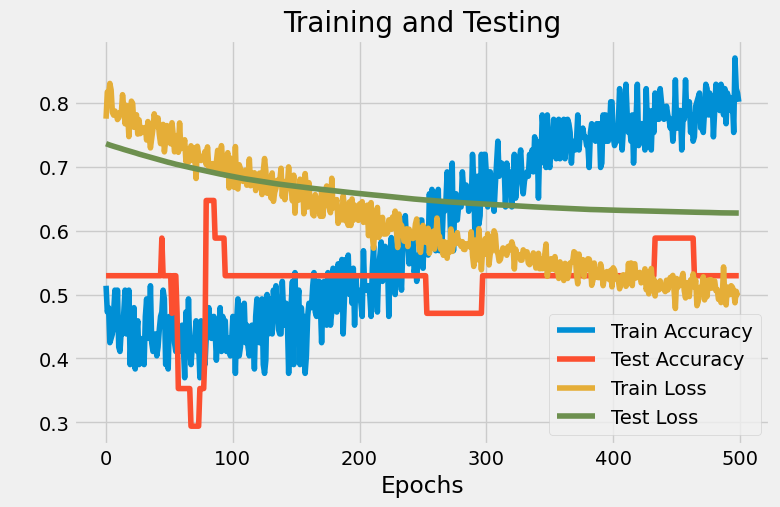

1/1 [==============================] - 0s 93ms/step


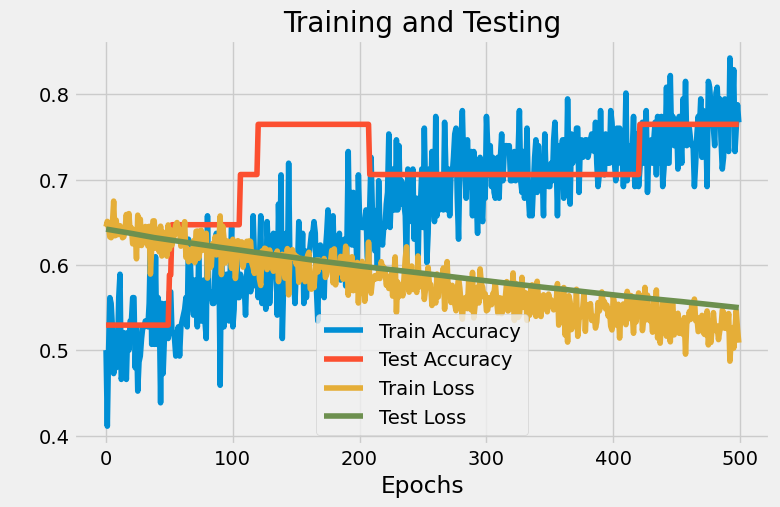

1/1 [==============================] - 0s 46ms/step


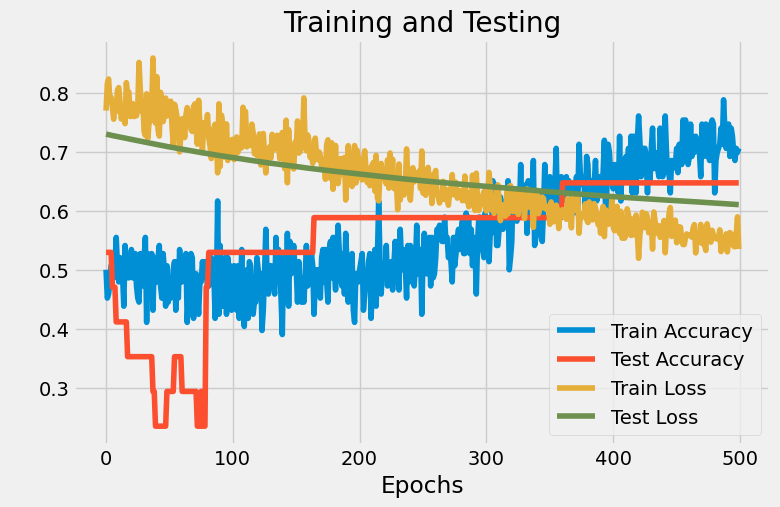

1/1 [==============================] - 0s 39ms/step


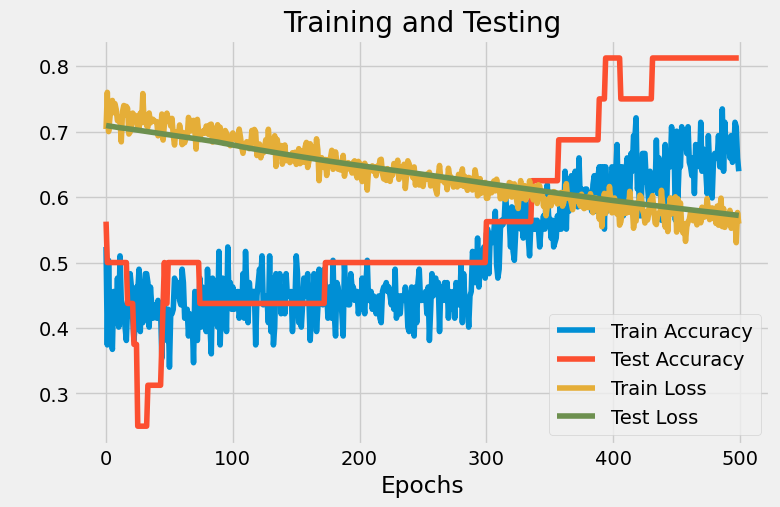

1/1 [==============================] - 0s 29ms/step


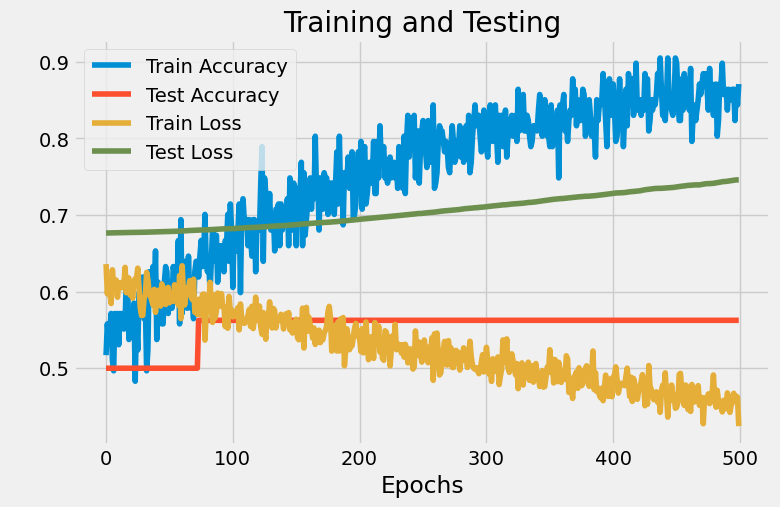

1/1 [==============================] - 0s 35ms/step


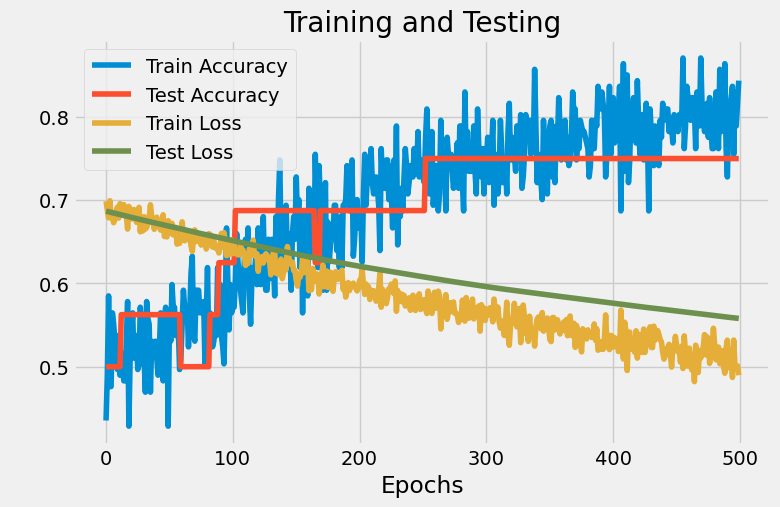

1/1 [==============================] - 0s 48ms/step


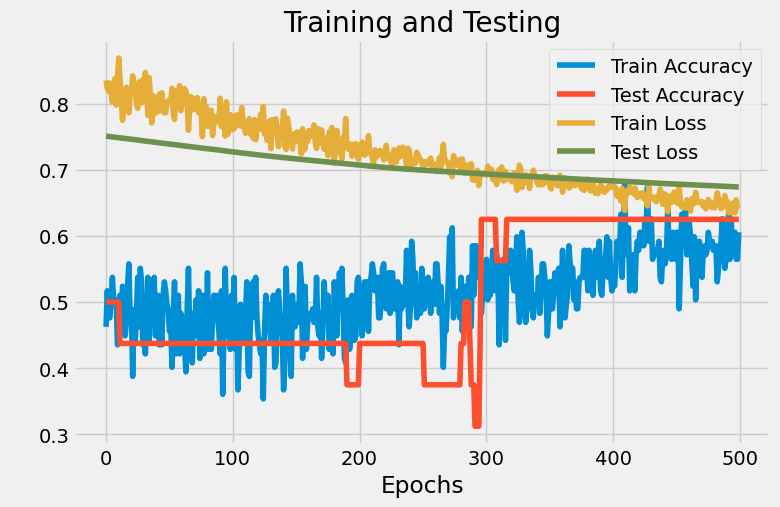

1/1 [==============================] - 0s 74ms/step


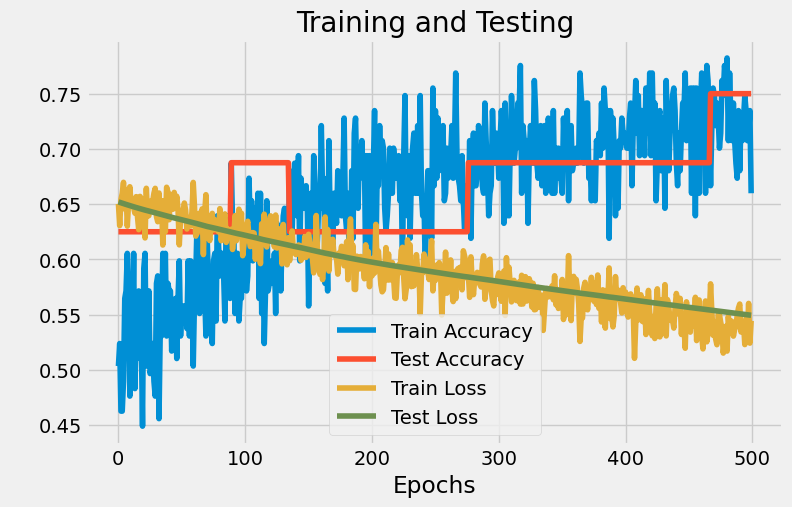

1/1 [==============================] - 0s 56ms/step


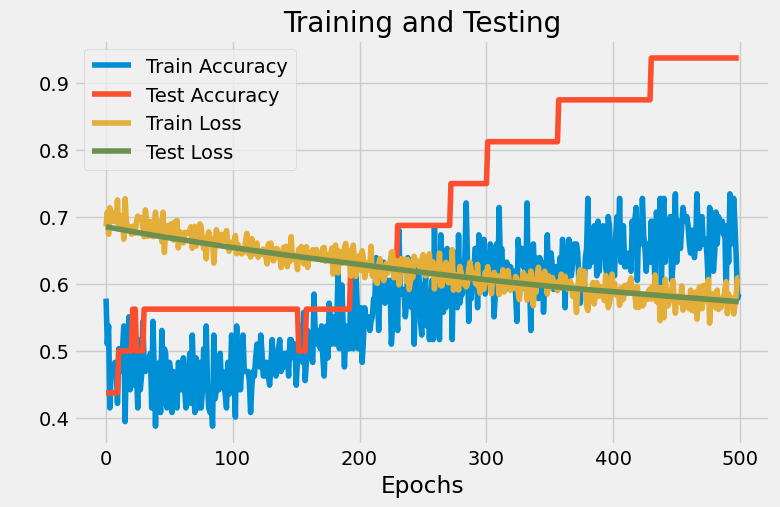

1/1 [==============================] - 0s 29ms/step


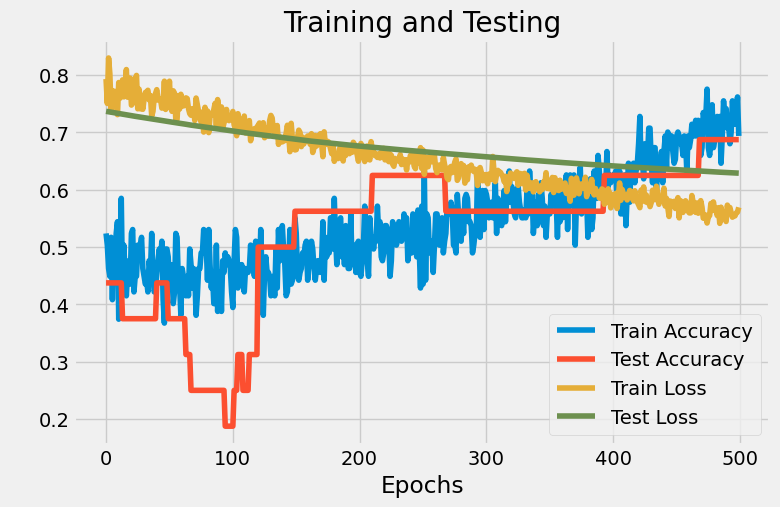

1/1 [==============================] - 0s 29ms/step
accuracy
Fold accuracies: [0.5294117647058824, 0.7647058823529411, 0.6470588235294118, 0.8125, 0.5625, 0.75, 0.625, 0.75, 0.9375, 0.6875]
Overall accuracy: 0.7066176470588236
Standard deviation: 0.11593189072553432
95% confidence interval: (0.6191989280561615, 0.7940363660614856)
precision
Fold precisions: [0.5384615384615384, 0.7272727272727273, 0.6, 0.7777777777777778, 0.5333333333333333, 0.7, 0.5714285714285714, 0.7272727272727273, 1.0, 0.6666666666666666]
Overall precision: 0.6842213342213342
Standard deviation: 0.13287644590907977
95% confidence interval: (0.5840255329253943, 0.7844171355172742)
recall
Fold recalls: [0.7777777777777778, 0.8888888888888888, 1.0, 0.875, 1.0, 0.875, 1.0, 0.8888888888888888, 0.8888888888888888, 0.8888888888888888]
Overall recall: 0.9083333333333334
Standard deviation: 0.06781419786518725
95% confidence interval: (0.8571978755186873, 0.9594687911479796)
f1
Fold f1s: [0.6363636363636364, 0.799999999999

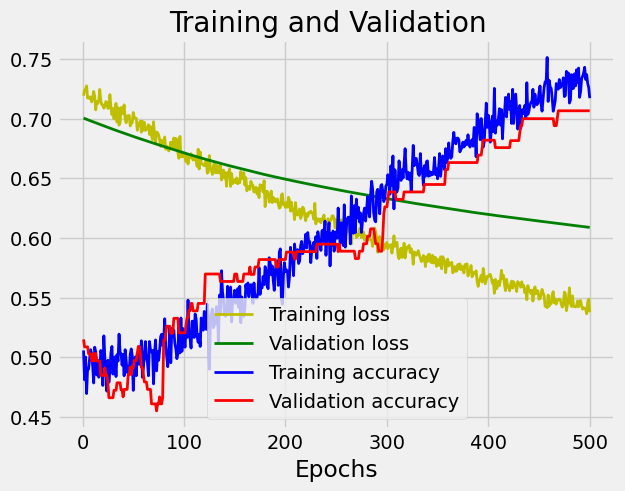

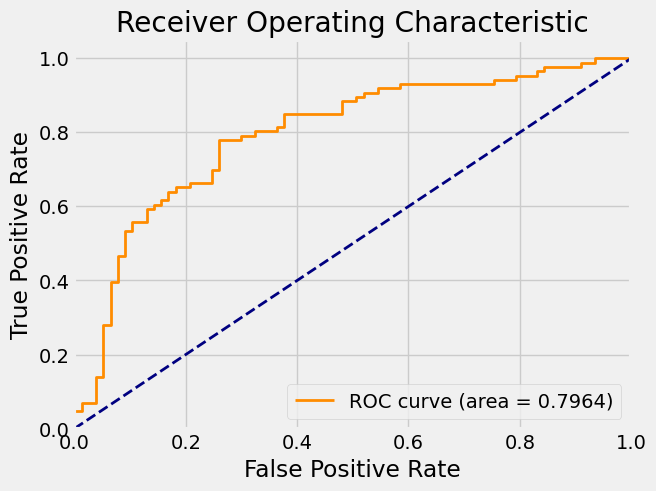

In [12]:
### deep model

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from scipy import stats
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv1D, MaxPooling1D, Input, concatenate
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Lasso
from tensorflow.keras.callbacks import ReduceLROnPlateau

accuracy_tr=[]
accuracy_te=[]
loss_tr=[]
loss_te=[]

# 对特征进行标准化处理
scaler = StandardScaler()
X_d = scaler.fit_transform(X)

# 训练LASSO回归模型，并获取系数
lasso = Lasso(alpha=0.05)
lasso.fit(X_d, y)
coefs = lasso.coef_

# 选择系数不为0的特征
selected_features = X_d[:, coefs != 0]
X_d = selected_features
X_train, X_test, y_train, y_test = train_test_split(X_d, y, test_size=0.2, random_state=84)
accuracy_scores_tt = []
accuracy_scores = []
precision_scores = []
recall_scores = []
f1_scores = []
roc_auc_scores = []

train_loss=[]
val_loss=[]
train_accuracy=[]
val_accuracy=[]
y_true_test_deep=[]
y_pred_probs_deep=[]

train_acc1=[]
train_loss1=[]
test_acc1=[]
test_loss1=[]

kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=84)

for train_idx, test_idx in kfold.split(X_d, y):
    X_train = X_d[train_idx]
    y_train = y.iloc[train_idx]
    X_test = X_d[test_idx]
    y_test = y.iloc[test_idx]

    models = []
    kk=3

        # 重塑数据以匹配 Conv1D 层的期望输入
    X_train = X_train.reshape((-1, X_train.shape[1], 1))
    X_test = X_test.reshape((-1, X_test.shape[1], 1))

    for i in range(kk):
        model = Sequential()
        model.add(Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=(X_train.shape[1], 1)))
        model.add(MaxPooling1D(pool_size=2))
        model.add(Flatten())
        model.add(Dense(128, activation='relu'))
        model.add(Dense(1, activation='sigmoid'))
        models.append(model)

    first_layer_train = np.zeros((len(X_train), kk))
    first_layer_test = np.zeros((len(X_test), kk))

    for i, model in enumerate(models):
        optimizer = tf.keras.optimizers.Adam(learning_rate=0.00005)
        
        model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])
        history1=model.fit(X_train, y_train, epochs=500, batch_size=32, verbose=0)
        y_pred_train = model.predict(X_train).ravel()
        first_layer_train[:, i] = y_pred_train
        y_pred_test = model.predict(X_test).ravel()
        first_layer_test[:, i] = y_pred_test

    input_layer = Input(shape=(kk,))
    x = Dense(16, activation='relu')(input_layer)
    x=Dropout(0.7)(x)
    output_layer = Dense(1, activation='sigmoid')(x)
    nn_model = Model(inputs=input_layer, outputs=output_layer)
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.00004)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.00001)
#     nn_model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy','precision','recall', 'f1_score', 'roc_auc'])
    nn_model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])
    history =nn_model.fit(first_layer_train, y_train, epochs=500, batch_size=16, verbose=0,validation_data=(first_layer_test, y_test)
#                           ,callbacks=[reduce_lr]
                         )

    train_loss.append(history.history['loss'])
    val_loss.append(history.history['val_loss'])
    train_accuracy.append(history.history['accuracy'])
    val_accuracy.append(history.history['val_accuracy'])

    
    train_acc1.append(np.mean(train_accuracy))
    test_acc1.append(np.mean(val_accuracy))
    train_loss1.append(np.mean(train_loss))
    test_loss1.append(np.mean(val_loss))
    
    plt.figure(figsize=(8, 5))
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Test Accuracy')
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Test Loss')
    plt.title('Training and Testing')
    plt.xlabel('Epochs')
    plt.ylabel(' ')
    plt.legend()
    plt.show()
    
    y_pred_tt=nn_model.predict(first_layer_train).ravel()
    y_pred_nn = nn_model.predict(first_layer_test).ravel()
    y_pred_probs_deep.extend(nn_model.predict(first_layer_test))
    y_true_test_deep.extend(y_test)

    y_pred_tt_binary=np.round(y_pred_tt)
    y_pred_nn_binary = np.round(y_pred_nn)
    accuracy_scores_tt.append(accuracy_score(y_train,y_pred_tt_binary))
    
    accuracy_scores.append(accuracy_score(y_test, y_pred_nn_binary))
    precision_scores.append(precision_score(y_test, y_pred_nn_binary))
    recall_scores.append(recall_score(y_test, y_pred_nn_binary))
    f1_scores.append(f1_score(y_test, y_pred_nn_binary))

fold_accuracies_tt=accuracy_scores_tt
fold_accuracies=accuracy_scores
fold_precisions=precision_scores
fold_recalls=recall_scores
fold_f1s=f1_scores

# 计算标准偏差
std_dev_acc = np.std(fold_accuracies)
std_dev_pre = np.std(fold_precisions)
std_dev_rec = np.std(fold_recalls)
std_dev_f1 = np.std(fold_f1s)

# 计算95%置信区间
confidence_interval_acc = stats.t.interval(0.95, len(fold_accuracies)-1, loc=np.mean(fold_accuracies), scale=stats.sem(fold_accuracies))
confidence_interval_pre = stats.t.interval(0.95, len(fold_precisions)-1, loc=np.mean(fold_precisions), scale=stats.sem(fold_precisions))
confidence_interval_rec = stats.t.interval(0.95, len(fold_recalls)-1, loc=np.mean(fold_recalls), scale=stats.sem(fold_recalls))
confidence_interval_f1 = stats.t.interval(0.95, len(fold_f1s)-1, loc=np.mean(fold_f1s), scale=stats.sem(fold_f1s))

overall_accuracy_tt=np.mean(fold_accuracies_tt)
overall_accuracy_deep=np.mean(fold_accuracies)
overall_precision_deep=np.mean(fold_precisions)
overall_recall_deep=np.mean(fold_recalls)
overall_f1_deep=np.mean(fold_f1s)

fpr_deep, tpr_deep, _ = roc_curve(y_true_test_deep, y_pred_probs_deep)
roc_auc_deep = auc(fpr_deep, tpr_deep)

print("accuracy")
print("Fold accuracies:", fold_accuracies)
print("Overall accuracy:", overall_accuracy_deep)
print("Standard deviation:", std_dev_acc)
print("95% confidence interval:", confidence_interval_acc)
print("precision")
print("Fold precisions:", fold_precisions)
print("Overall precision:", overall_precision_deep)
print("Standard deviation:", std_dev_pre)
print("95% confidence interval:", confidence_interval_pre)
print("recall")
print("Fold recalls:", fold_recalls)
print("Overall recall:", overall_recall_deep)
print("Standard deviation:", std_dev_rec)
print("95% confidence interval:", confidence_interval_rec)
print("f1")
print("Fold f1s:", fold_f1s)
print("Overall f1:", overall_f1_deep)
print("Standard deviation:", std_dev_f1)
print("95% confidence interval:", confidence_interval_f1)

mean_train_loss = np.mean(train_loss, axis=0)
mean_val_loss = np.mean(val_loss, axis=0)
std_train_loss = np.std(train_loss, axis=0)
std_val_loss = np.std(val_loss, axis=0)
mean_train_accuracy = np.mean(train_accuracy, axis=0)
mean_val_accuracy = np.mean(val_accuracy, axis=0)
std_train_accuracy= np.std(train_accuracy, axis=0)
std_val_accuracy = np.std(val_accuracy, axis=0)
epochs = range(1, max(len(mean_train_loss), len(mean_val_loss)) + 1)
plt.plot(epochs, mean_train_loss, 'y-',lw=2, label='Training loss')
plt.plot(epochs, mean_val_loss, 'g-', lw=2,label='Validation loss')
plt.plot(epochs, mean_train_accuracy, 'b-', lw=2,label='Training accuracy')
plt.plot(epochs, mean_val_accuracy, 'r-',lw=2, label='Validation accuracy')
plt.title('Training and Validation  ')
plt.xlabel('Epochs')
plt.ylabel('')
plt.legend()
plt.show()

# 绘制ROC曲线
plt.figure()
plt.plot(fpr_deep, tpr_deep, color='darkorange', lw=2, label='ROC curve (area = %0.4f)' % roc_auc_deep)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

In [13]:
from sklearn.metrics import roc_curve, auc
import numpy as np


# 确定每份的大小
n = len(y_true_test_deep)
n_splits = 10
split_size = n // n_splits

# 计算每份的AUC值
auc_values = []
for i in range(n_splits):
    start_index = i * split_size
    end_index = (i + 1) * split_size if i < n_splits - 1 else n
    y_true_split = y_true_test_deep[start_index:end_index]
    y_pred_split = y_pred_probs_deep[start_index:end_index]
    
    # 计算ROC曲线
    fpr_split, tpr_split, _ = roc_curve(y_true_split, y_pred_split)
    # 计算AUC值
    auc_split = auc(fpr_split, tpr_split)
    auc_values.append(auc_split)

# 打印每份的AUC值
for i, auc in enumerate(auc_values):
    print(f"AUC for split {i+1}: {auc}")

AUC for split 1: 0.6875
AUC for split 2: 0.921875
AUC for split 3: 0.84375
AUC for split 4: 1.0
AUC for split 5: 0.53125
AUC for split 6: 0.96875
AUC for split 7: 0.8125
AUC for split 8: 0.9365079365079365
AUC for split 9: 0.8095238095238095
AUC for split 10: 0.7023809523809524


In [14]:
df_acc=df_acc.append({'Model':'deep','1':0.5294117647058824, '2':0.8235294117647058, '3':0.6470588235294118, 
                      '4':0.875, '5':0.5625, '6':0.75, 
                      '7':0.5625, '8':0.625, '9':0.75, '10':0.1875},ignore_index=True)
df_pre=df_pre.append({'Model':'deep','1':0.5384615384615384, '2':0.8,'3':0.6, 
                      '4':0.875, '5':0.5333333333333333,   '6':0.7, 
                      '7': 0.5333333333333333,  '8':0.6153846153846154,  '9':0.7272727272727273, '10':0.25},ignore_index=True)
df_rec=df_rec.append({'Model':'deep','1':0.7777777777777778, '2':0.8888888888888888,'3':1.0, 
                      '4':0.875, '5':1.0,   '6':0.875, 
                      '7': 0.8888888888888888,  '8':1.0,  '9':0.8888888888888888, '10':0.2222222222222222},ignore_index=True)
df_f1=df_f1.append({'Model':'deep','1':0.6363636363636364, '2':0.8421052631578948,'3':0.7499999999999999, 
                    '4':0.875, '5':0.6956521739130436,   '6':0.7777777777777777, 
                    '7': 0.6956521739130436,  '8':0.7272727272727274,  '9':0.7999999999999999, '10':0.23529411764705882},ignore_index=True)
df_auc=df_auc.append({'Model':'deep','1':0.71875, '2':0.921875,'3':0.953125, 
                    '4':0.96875, '5':0.53125,   '6':0.96875, 
                    '7':0.828125,  '8':0.9365079365079365,  '9':0.873015873015873, '10':0.7738095238095238},ignore_index=True)

In [15]:
a,b,c,d,e,y_scores_dt_1,y_true_dt_1=crosspredict(model_dt_fs,X_pre,y,10)
a,b,c,d,e,y_scores_rf_1,y_true_rf_1=crosspredict(model_rf_fs,X_pre,y,10)
a,b,c,d,e,y_scores_ada_1,y_true_ada_1=crosspredict(model_ada_fs,X_pre,y,10)
a,b,c,d,e,y_scores_xgb_1,y_true_xgb_1=crosspredict(model_xgb_fs,X_pre,y,10)
a,b,c,d,e,y_scores_gnb_1,y_true_gnb_1=crosspredict(model_gnb_fs,X_pre,y,10)
a,b,c,d,e,y_scores_voting,y_true_voting_1=crosspredict(model_voting_hard,X_pre,y,10)
newdf=pd.DataFrame(data=[y_scores_voting,y_scores_dt_1,y_scores_rf_1,y_scores_ada_1,y_scores_xgb_1,y_scores_gnb_1])
y_scores_proba_voting=[]

for i in range(163):
    sc=np.sum(newdf.iloc[1][i]+newdf.iloc[2][i]+newdf.iloc[3][i]+newdf.iloc[4][i]+newdf.iloc[5][i])
    y_scores_proba_voting.append(sc/5)

cross-validate across the entire data set
the confusion_matrix of the model is : 
 [[68  9]
 [24 62]]
the accuracy of the model is :  0.7975460122699386
the precision score of the model is :  0.8732394366197183
the recall score of the model is : 0.7209302325581395
the f1_score of the model  is : 0.7898089171974522
the weighted_f1 of the model is : 0.7968592878552209
the classification_report is :
               precision    recall  f1-score   support

           0     0.7391    0.8831    0.8047        77
           1     0.8732    0.7209    0.7898        86

    accuracy                         0.7975       163
   macro avg     0.8062    0.8020    0.7973       163
weighted avg     0.8099    0.7975    0.7969       163

cross-validate across the entire data set
the confusion_matrix of the model is : 
 [[62 15]
 [28 58]]
the accuracy of the model is :  0.7361963190184049
the precision score of the model is :  0.7945205479452054
the recall score of the model is : 0.6744186046511628
the f1_

In [16]:
### with auc
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import numpy as np
import pandas as pd

for j in range(1):
    # 获取预测概率
    predictions_prob = cross_val_predict(model_Stacking_cross, X_pre, y, cv=10, method='predict_proba')
    predictions = cross_val_predict(model_Stacking_cross, X_pre, y, cv=10)
    
    # 计算整体的准确率
    overall_accuracy = accuracy_score(y, predictions)
    overall_precision = precision_score(y, predictions)
    overall_recall = recall_score(y, predictions)
    overall_f1 = f1_score(y, predictions)
    
    # 初始化一个列表来存储每一折的指标
    fold_accuracies = []
    fold_precisions = []
    fold_recalls = []
    fold_f1s = []
    fold_aucs = []  # 添加 AUC 存储列表

    # 使用 StratifiedKFold 进行十折交叉验证
    skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    
    for i, (train_index, test_index) in enumerate(skf.split(X_pre, y)):
        # 获取第i折的测试集的真实标签和预测标签
        y_true = y.iloc[test_index]
        y_pred = predictions[test_index]
        y_pred_prob = predictions_prob[test_index][:, 1]  # 假设是二分类问题，取正类的概率

        # 计算第i折的指标
        fold_accuracy = accuracy_score(y_true, y_pred)
        fold_accuracies.append(fold_accuracy)
        fold_precision = precision_score(y_true, y_pred)
        fold_precisions.append(fold_precision)
        fold_recall = recall_score(y_true, y_pred)
        fold_recalls.append(fold_recall)
        fold_f1 = f1_score(y_true, y_pred)
        fold_f1s.append(fold_f1)
        
        # 计算第i折的 AUC
        fold_auc = roc_auc_score(y_true, y_pred_prob)
        fold_aucs.append(fold_auc)

    print("Stacking")
    print("acc-mean:", overall_accuracy)
    print("pre-mean:", overall_precision)
    print("rec-mean:", overall_recall)
    print("f1-mean:", overall_f1)
    print("auc-mean:", np.mean(fold_aucs))  # 输出整体 AUC 均值

    # 将结果存储到 DataFrame 中
    df_acc = df_acc.append({'Model': "Stacking", '1': fold_accuracies[0], '2': fold_accuracies[1], '3': fold_accuracies[2], '4': fold_accuracies[3],
                            '5': fold_accuracies[4], '6': fold_accuracies[5], '7': fold_accuracies[6], '8': fold_accuracies[7],
                            '9': fold_accuracies[8], '10': fold_accuracies[9]}, ignore_index=True)
    df_pre = df_pre.append({'Model': "Stacking", '1': fold_precisions[0], '2': fold_precisions[1], '3': fold_precisions[2], '4': fold_precisions[3],
                            '5': fold_precisions[4], '6': fold_precisions[5], '7': fold_precisions[6], '8': fold_precisions[7],
                            '9': fold_precisions[8], '10': fold_precisions[9]}, ignore_index=True)
    df_rec = df_rec.append({'Model': "Stacking", '1': fold_recalls[0], '2': fold_recalls[1], '3': fold_recalls[2], '4': fold_recalls[3],
                            '5': fold_recalls[4], '6': fold_recalls[5], '7': fold_recalls[6], '8': fold_recalls[7],
                            '9': fold_recalls[8], '10': fold_recalls[9]}, ignore_index=True)
    df_f1 = df_f1.append({'Model': "Stacking", '1': fold_f1s[0], '2': fold_f1s[1], '3': fold_f1s[2], '4': fold_f1s[3],
                          '5': fold_f1s[4], '6': fold_f1s[5], '7': fold_f1s[6], '8': fold_f1s[7],
                          '9': fold_f1s[8], '10': fold_f1s[9]}, ignore_index=True)
    df_auc = df_auc.append({'Model': "Stacking", '1': fold_aucs[0], '2': fold_aucs[1], '3': fold_aucs[2], '4': fold_aucs[3],
                            '5': fold_aucs[4], '6': fold_aucs[5], '7': fold_aucs[6], '8': fold_aucs[7],
                            '9': fold_aucs[8], '10': fold_aucs[9]}, ignore_index=True)

Stacking
acc-mean: 0.852760736196319
pre-mean: 0.918918918918919
rec-mean: 0.7906976744186046
f1-mean: 0.85
auc-mean: 0.9086557539682539


In [17]:
### voting
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import numpy as np
import pandas as pd

for j in range(1):
    # 获取预测概率
    predictions = cross_val_predict(model_voting_hard, X_pre, y, cv=10)
    # 初始化一个列表来存储每一折的指标
    fold_accuracies = []
    fold_precisions = []
    fold_recalls = []
    fold_f1s = []
    fold_aucs = []  # 添加 AUC 存储列表

    # 使用 StratifiedKFold 进行十折交叉验证
    skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    
    for i, (train_index, test_index) in enumerate(skf.split(X_pre, y)):
        # 获取第i折的测试集的真实标签和预测标签
        y_true = y.iloc[test_index]
        y_pred = predictions[test_index]
        y_pred_prob = np.array(y_scores_proba_voting)[test_index] # 假设是二分类问题，取正类的概率

        # 计算第i折的指标
        fold_accuracy = accuracy_score(y_true, y_pred)
        fold_accuracies.append(fold_accuracy)
        fold_precision = precision_score(y_true, y_pred)
        fold_precisions.append(fold_precision)
        fold_recall = recall_score(y_true, y_pred)
        fold_recalls.append(fold_recall)
        fold_f1 = f1_score(y_true, y_pred)
        fold_f1s.append(fold_f1)
        
        # 计算第i折的 AUC
        fold_auc = roc_auc_score(y_true, y_pred_prob)
        fold_aucs.append(fold_auc)

    # 将结果存储到 DataFrame 中
    df_acc = df_acc.append({'Model': "Voting", '1': fold_accuracies[0], '2': fold_accuracies[1], '3': fold_accuracies[2], '4': fold_accuracies[3],
                            '5': fold_accuracies[4], '6': fold_accuracies[5], '7': fold_accuracies[6], '8': fold_accuracies[7],
                            '9': fold_accuracies[8], '10': fold_accuracies[9]}, ignore_index=True)
    df_pre = df_pre.append({'Model': "Voting", '1': fold_precisions[0], '2': fold_precisions[1], '3': fold_precisions[2], '4': fold_precisions[3],
                            '5': fold_precisions[4], '6': fold_precisions[5], '7': fold_precisions[6], '8': fold_precisions[7],
                            '9': fold_precisions[8], '10': fold_precisions[9]}, ignore_index=True)
    df_rec = df_rec.append({'Model': "Voting", '1': fold_recalls[0], '2': fold_recalls[1], '3': fold_recalls[2], '4': fold_recalls[3],
                            '5': fold_recalls[4], '6': fold_recalls[5], '7': fold_recalls[6], '8': fold_recalls[7],
                            '9': fold_recalls[8], '10': fold_recalls[9]}, ignore_index=True)
    df_f1 = df_f1.append({'Model': "Voting", '1': fold_f1s[0], '2': fold_f1s[1], '3': fold_f1s[2], '4': fold_f1s[3],
                          '5': fold_f1s[4], '6': fold_f1s[5], '7': fold_f1s[6], '8': fold_f1s[7],
                          '9': fold_f1s[8], '10': fold_f1s[9]}, ignore_index=True)
    df_auc = df_auc.append({'Model': "Voting", '1': fold_aucs[0], '2': fold_aucs[1], '3': fold_aucs[2], '4': fold_aucs[3],
                            '5': fold_aucs[4], '6': fold_aucs[5], '7': fold_aucs[6], '8': fold_aucs[7],
                            '9': fold_aucs[8], '10': fold_aucs[9]}, ignore_index=True)

In [ ]:
### 存储

In [24]:
# 将宽格式转换为长格式
accuracy_long = df_acc.melt(id_vars='Model', var_name='Fold', value_name='Accuracy')
precision_long = df_pre.melt(id_vars='Model', var_name='Fold', value_name='Precision')
recall_long = df_rec.melt(id_vars='Model', var_name='Fold', value_name='Recall')
f1_long = df_f1.melt(id_vars='Model', var_name='Fold', value_name='F1')
auc_long = df_auc.melt(id_vars='Model', var_name='Fold', value_name='AUC')

# 合并四张表
combined_df = accuracy_long.merge(precision_long, on=['Model', 'Fold'])
combined_df = combined_df.merge(recall_long, on=['Model', 'Fold'])
combined_df = combined_df.merge(f1_long, on=['Model', 'Fold'])
combined_df = combined_df.merge(auc_long, on=['Model', 'Fold'])

print(combined_df.head())
from scipy.stats import friedmanchisquare

data1_acc = combined_df[combined_df['Model'] == 'SVC']['Accuracy']
data2_acc = combined_df[combined_df['Model'] == 'SVC+']['Accuracy']
data3_acc = combined_df[combined_df['Model'] == 'KNN']['Accuracy']
data4_acc = combined_df[combined_df['Model'] == 'KNN+']['Accuracy']
data5_acc = combined_df[combined_df['Model'] == 'LR']['Accuracy']
data6_acc = combined_df[combined_df['Model'] == 'LR+']['Accuracy']
data7_acc = combined_df[combined_df['Model'] == 'GNB']['Accuracy']
data8_acc = combined_df[combined_df['Model'] == 'GNB+']['Accuracy']
data9_acc = combined_df[combined_df['Model'] == 'DT']['Accuracy']
data10_acc = combined_df[combined_df['Model'] == 'DT+']['Accuracy']
data11_acc = combined_df[combined_df['Model'] == 'RF']['Accuracy']
data12_acc = combined_df[combined_df['Model'] == 'RF+']['Accuracy']
data13_acc = combined_df[combined_df['Model'] == 'Ada']['Accuracy']
data14_acc = combined_df[combined_df['Model'] == 'Ada+']['Accuracy']
data15_acc = combined_df[combined_df['Model'] == 'GBDT']['Accuracy']
data16_acc = combined_df[combined_df['Model'] == 'GBDT+']['Accuracy']
data17_acc = combined_df[combined_df['Model'] == 'XGB']['Accuracy']
data18_acc = combined_df[combined_df['Model'] == 'XGB+']['Accuracy']
data19_acc = combined_df[combined_df['Model'] == 'LGB']['Accuracy']
data20_acc = combined_df[combined_df['Model'] == 'LGB+']['Accuracy']
data21_acc = combined_df[combined_df['Model'] == 'early']['Accuracy']
data22_acc = combined_df[combined_df['Model'] == 'deep']['Accuracy']
data23_acc = combined_df[combined_df['Model'] == 'Stacking']['Accuracy']
data24_acc = combined_df[combined_df['Model'] == 'Voting']['Accuracy']

data1_pre = combined_df[combined_df['Model'] == 'SVC']['Precision']
data2_pre = combined_df[combined_df['Model'] == 'SVC+']['Precision']
data3_pre = combined_df[combined_df['Model'] == 'KNN']['Precision']
data4_pre = combined_df[combined_df['Model'] == 'KNN+']['Precision']
data5_pre = combined_df[combined_df['Model'] == 'LR']['Precision']
data6_pre = combined_df[combined_df['Model'] == 'LR+']['Precision']
data7_pre = combined_df[combined_df['Model'] == 'GNB']['Precision']
data8_pre = combined_df[combined_df['Model'] == 'GNB+']['Precision']
data9_pre = combined_df[combined_df['Model'] == 'DT']['Precision']
data10_pre = combined_df[combined_df['Model'] == 'DT+']['Precision']
data11_pre = combined_df[combined_df['Model'] == 'RF']['Precision']
data12_pre = combined_df[combined_df['Model'] == 'RF+']['Precision']
data13_pre = combined_df[combined_df['Model'] == 'Ada']['Precision']
data14_pre = combined_df[combined_df['Model'] == 'Ada+']['Precision']
data15_pre = combined_df[combined_df['Model'] == 'GBDT']['Precision']
data16_pre = combined_df[combined_df['Model'] == 'GBDT+']['Precision']
data17_pre = combined_df[combined_df['Model'] == 'XGB']['Precision']
data18_pre = combined_df[combined_df['Model'] == 'XGB+']['Precision']
data19_pre = combined_df[combined_df['Model'] == 'LGB']['Precision']
data20_pre = combined_df[combined_df['Model'] == 'LGB+']['Precision']
data21_pre = combined_df[combined_df['Model'] == 'early']['Precision']
data22_pre = combined_df[combined_df['Model'] == 'deep']['Precision']
data23_pre = combined_df[combined_df['Model'] == 'Stacking']['Precision']
data24_pre = combined_df[combined_df['Model'] == 'Voting']['Precision']

data1_rec = combined_df[combined_df['Model'] == 'SVC']['Recall']
data2_rec = combined_df[combined_df['Model'] == 'SVC+']['Recall']
data3_rec = combined_df[combined_df['Model'] == 'KNN']['Recall']
data4_rec = combined_df[combined_df['Model'] == 'KNN+']['Recall']
data5_rec = combined_df[combined_df['Model'] == 'LR']['Recall']
data6_rec = combined_df[combined_df['Model'] == 'LR+']['Recall']
data7_rec = combined_df[combined_df['Model'] == 'GNB']['Recall']
data8_rec = combined_df[combined_df['Model'] == 'GNB+']['Recall']
data9_rec = combined_df[combined_df['Model'] == 'DT']['Recall']
data10_rec = combined_df[combined_df['Model'] == 'DT+']['Recall']
data11_rec = combined_df[combined_df['Model'] == 'RF']['Recall']
data12_rec = combined_df[combined_df['Model'] == 'RF+']['Recall']
data13_rec = combined_df[combined_df['Model'] == 'Ada']['Recall']
data14_rec = combined_df[combined_df['Model'] == 'Ada+']['Recall']
data15_rec = combined_df[combined_df['Model'] == 'GBDT']['Recall']
data16_rec = combined_df[combined_df['Model'] == 'GBDT+']['Recall']
data17_rec = combined_df[combined_df['Model'] == 'XGB']['Recall']
data18_rec = combined_df[combined_df['Model'] == 'XGB+']['Recall']
data19_rec = combined_df[combined_df['Model'] == 'LGB']['Recall']
data20_rec = combined_df[combined_df['Model'] == 'LGB+']['Recall']
data21_rec = combined_df[combined_df['Model'] == 'early']['Recall']
data22_rec = combined_df[combined_df['Model'] == 'deep']['Recall']
data23_rec = combined_df[combined_df['Model'] == 'Stacking']['Recall']
data24_rec = combined_df[combined_df['Model'] == 'Voting']['Recall']

data1_f1 = combined_df[combined_df['Model'] == 'SVC']['F1']
data2_f1 = combined_df[combined_df['Model'] == 'SVC+']['F1']
data3_f1 = combined_df[combined_df['Model'] == 'KNN']['F1']
data4_f1 = combined_df[combined_df['Model'] == 'KNN+']['F1']
data5_f1 = combined_df[combined_df['Model'] == 'LR']['F1']
data6_f1 = combined_df[combined_df['Model'] == 'LR+']['F1']
data7_f1 = combined_df[combined_df['Model'] == 'GNB']['F1']
data8_f1 = combined_df[combined_df['Model'] == 'GNB+']['F1']
data9_f1 = combined_df[combined_df['Model'] == 'DT']['F1']
data10_f1 = combined_df[combined_df['Model'] == 'DT+']['F1']
data11_f1 = combined_df[combined_df['Model'] == 'RF']['F1']
data12_f1 = combined_df[combined_df['Model'] == 'RF+']['F1']
data13_f1 = combined_df[combined_df['Model'] == 'Ada']['F1']
data14_f1 = combined_df[combined_df['Model'] == 'Ada+']['F1']
data15_f1 = combined_df[combined_df['Model'] == 'GBDT']['F1']
data16_f1 = combined_df[combined_df['Model'] == 'GBDT+']['F1']
data17_f1 = combined_df[combined_df['Model'] == 'XGB']['F1']
data18_f1 = combined_df[combined_df['Model'] == 'XGB+']['F1']
data19_f1 = combined_df[combined_df['Model'] == 'LGB']['F1']
data20_f1 = combined_df[combined_df['Model'] == 'LGB+']['F1']
data21_f1 = combined_df[combined_df['Model'] == 'early']['F1']
data22_f1 = combined_df[combined_df['Model'] == 'deep']['F1']
data23_f1 = combined_df[combined_df['Model'] == 'Stacking']['F1']
data24_f1 = combined_df[combined_df['Model'] == 'Voting']['F1']

data1_auc = combined_df[combined_df['Model'] == 'SVC']['AUC']
data2_auc = combined_df[combined_df['Model'] == 'SVC+']['AUC']
data3_auc = combined_df[combined_df['Model'] == 'KNN']['AUC']
data4_auc = combined_df[combined_df['Model'] == 'KNN+']['AUC']
data5_auc = combined_df[combined_df['Model'] == 'LR']['AUC']
data6_auc = combined_df[combined_df['Model'] == 'LR+']['AUC']
data7_auc = combined_df[combined_df['Model'] == 'GNB']['AUC']
data8_auc = combined_df[combined_df['Model'] == 'GNB+']['AUC']
data9_auc = combined_df[combined_df['Model'] == 'DT']['AUC']
data10_auc = combined_df[combined_df['Model'] == 'DT+']['AUC']
data11_auc = combined_df[combined_df['Model'] == 'RF']['AUC']
data12_auc = combined_df[combined_df['Model'] == 'RF+']['AUC']
data13_auc = combined_df[combined_df['Model'] == 'Ada']['AUC']
data14_auc = combined_df[combined_df['Model'] == 'Ada+']['AUC']
data15_auc = combined_df[combined_df['Model'] == 'GBDT']['AUC']
data16_auc = combined_df[combined_df['Model'] == 'GBDT+']['AUC']
data17_auc = combined_df[combined_df['Model'] == 'XGB']['AUC']
data18_auc = combined_df[combined_df['Model'] == 'XGB+']['AUC']
data19_auc = combined_df[combined_df['Model'] == 'LGB']['AUC']
data20_auc = combined_df[combined_df['Model'] == 'LGB+']['AUC']
data21_auc = combined_df[combined_df['Model'] == 'early']['AUC']
data22_auc = combined_df[combined_df['Model'] == 'deep']['AUC']
data23_auc = combined_df[combined_df['Model'] == 'Stacking']['AUC']
data24_auc = combined_df[combined_df['Model'] == 'Voting']['AUC']

  Model Fold  Accuracy  Precision    Recall        F1       AUC
0   SVC    1  0.529412   0.600000  0.333333  0.428571  0.416667
1  SVC+    1  0.823529   0.800000  0.888889  0.842105  0.916667
2   KNN    1  0.588235   0.666667  0.444444  0.533333  0.659722
3  KNN+    1  0.764706   1.000000  0.555556  0.714286  0.916667
4    LR    1  0.529412   0.545455  0.666667  0.600000  0.513889


### 绘制ROC曲线

In [25]:
a,b,c,d,e,y_scores_gnb_1,y_true_gnb_1=crosspredict(yuan4,X_yuan,y_yuan,10)
y_scores_gnb_o=crosspredict_proba(yuan4,X_yuan,y_yuan,10)
y_scores_lr_o=crosspredict_proba(yuan3,X_yuan,y_yuan,10)
y_scores_svm_o=crosspredict_proba(yuan1,X_yuan,y_yuan,10)
y_scores_knn_o=crosspredict_proba(yuan2,X_yuan,y_yuan,10)
y_scores_ada_o=crosspredict_proba(yuan8,X_yuan,y_yuan,10)
y_scores_rf_o=crosspredict_proba(yuan7,X_yuan,y_yuan,10)
y_scores_dt_o=crosspredict_proba(yuan6,X_yuan,y_yuan,10)
y_scores_xgb_o=crosspredict_proba(yuan10,X_yuan,y_yuan,10)
y_scores_lgb_o=crosspredict_proba(yuan11,X_yuan,y_yuan,10)
y_scores_gbdt_o=crosspredict_proba(yuan9,X_yuan,y_yuan,10)
y_scores_gnb=crosspredict_proba(model_GNB_fs,X_pre,y,10)
y_scores_lr=crosspredict_proba(model_lr_fs,X_pre,y,10)
y_scores_svm=crosspredict_proba(model_SVC_fs,X_pre,y,10)
y_scores_knn=crosspredict_proba(model_KN_fs,X_pre,y,10)
y_scores_ada=crosspredict_proba(model_ada_fs,X_pre,y,10)
y_scores_rf=crosspredict_proba(model_rf_fs,X_pre,y,10)
y_scores_dt=crosspredict_proba(model_dt_fs,X_pre,y,10)
y_scores_xgb=crosspredict_proba(model_xgb_fs,X_pre,y,10)
y_scores_lgb=crosspredict_proba(model_Lightgbm_fs,X_pre,y,10)
y_scores_gbdt=crosspredict_proba(model_gb_fs,X_pre,y,10)

cross-validate across the entire data set
the confusion_matrix of the model is : 
 [[62 16]
 [42 45]]
the accuracy of the model is :  0.6484848484848484
the precision score of the model is :  0.7377049180327869
the recall score of the model is : 0.5172413793103449
the f1_score of the model  is : 0.6081081081081081
the weighted_f1 of the model is : 0.6427167427167427
the classification_report is :
               precision    recall  f1-score   support

           0     0.5962    0.7949    0.6813        78
           1     0.7377    0.5172    0.6081        87

    accuracy                         0.6485       165
   macro avg     0.6669    0.6561    0.6447       165
weighted avg     0.6708    0.6485    0.6427       165

cross-validate across the entire data set
cross-validate across the entire data set
cross-validate across the entire data set
cross-validate across the entire data set
cross-validate across the entire data set
cross-validate across the entire data set
cross-validate acros

In [26]:
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

def evaluate_model(X, y, model):
    # 存储每一折的AUC值和ROC曲线数据
    y_pred_probas=[]
    y_trues=[]

    # 进行十折交叉验证
    for i, (train_index, test_index) in enumerate(skf.split(X, y)):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]
        
        # 训练模型
        model.fit(X_train, y_train)
        
        # 预测测试集
        y_pred_proba = model.predict_proba(X_test)[:, 1]
        
        y_pred_probas.extend(y_pred_proba)
        
        y_trues.extend(y_test)

    return y_pred_probas,y_trues

y_scores_stacking,y_true_stacking=evaluate_model(X_pre,y,model_Stacking_cross)

In [28]:
a,b,c,d,e,y_scores_dt_1,y_true=crosspredict(model_dt_fs,X_pre,y,10)
a,b,c,d,e,y_scores_rf_1,y_true=crosspredict(model_rf_fs,X_pre,y,10)
a,b,c,d,e,y_scores_ada_1,y_true=crosspredict(model_ada_fs,X_pre,y,10)
a,b,c,d,e,y_scores_xgb_1,y_true=crosspredict(model_xgb_fs,X_pre,y,10)
a,b,c,d,e,y_scores_gnb_1,y_true=crosspredict(model_gnb_fs,X_pre,y,10)
a,b,c,d,e,y_scores_voting,y_true=crosspredict(model_voting_hard,X_pre,y,10)
newdf=pd.DataFrame(data=[y_scores_voting,y_scores_dt_1,y_scores_rf_1,y_scores_ada_1,y_scores_xgb_1,y_scores_gnb_1])
y_scores_proba_voting=[]

for i in range(163):
    sc=np.sum(newdf.iloc[1][i]+newdf.iloc[2][i]+newdf.iloc[3][i]+newdf.iloc[4][i]+newdf.iloc[5][i])
    y_scores_proba_voting.append(sc/5)

cross-validate across the entire data set
the confusion_matrix of the model is : 
 [[68  9]
 [24 62]]
the accuracy of the model is :  0.7975460122699386
the precision score of the model is :  0.8732394366197183
the recall score of the model is : 0.7209302325581395
the f1_score of the model  is : 0.7898089171974522
the weighted_f1 of the model is : 0.7968592878552209
the classification_report is :
               precision    recall  f1-score   support

           0     0.7391    0.8831    0.8047        77
           1     0.8732    0.7209    0.7898        86

    accuracy                         0.7975       163
   macro avg     0.8062    0.8020    0.7973       163
weighted avg     0.8099    0.7975    0.7969       163

cross-validate across the entire data set
the confusion_matrix of the model is : 
 [[62 15]
 [28 58]]
the accuracy of the model is :  0.7361963190184049
the precision score of the model is :  0.7945205479452054
the recall score of the model is : 0.6744186046511628
the f1_

In [27]:
a,b,c,d,e,y_scores_dt_1,y_true_o=crosspredict(yuan6,X_yuan,y_yuan,10)

cross-validate across the entire data set
the confusion_matrix of the model is : 
 [[56 22]
 [31 56]]
the accuracy of the model is :  0.6787878787878788
the precision score of the model is :  0.717948717948718
the recall score of the model is : 0.6436781609195402
the f1_score of the model  is : 0.6787878787878788
the weighted_f1 of the model is : 0.6787878787878788
the classification_report is :
               precision    recall  f1-score   support

           0     0.6437    0.7179    0.6788        78
           1     0.7179    0.6437    0.6788        87

    accuracy                         0.6788       165
   macro avg     0.6808    0.6808    0.6788       165
weighted avg     0.6828    0.6788    0.6788       165



In [29]:
fpr_gnb_o, tpr_gnb_o, thresholds_gnb_o = metrics.roc_curve(y_true_o, y_scores_gnb_o[:,1])
fpr_lr_o, tpr_lr_o, thresholds_lr_o = metrics.roc_curve(y_true_o, y_scores_lr_o[:,1])
fpr_svm_o, tpr_svm_o, thresholds_svm_o = metrics.roc_curve(y_true_o, y_scores_svm_o[:,1])
fpr_knn_o, tpr_knn_o, thresholds_knn_o = metrics.roc_curve(y_true_o, y_scores_knn_o[:,1])
fpr_ada_o, tpr_ada_o, thresholds_ada_o = metrics.roc_curve(y_true_o, y_scores_ada_o[:,1])
fpr_rf_o, tpr_rf_o, thresholds_rf_o = metrics.roc_curve(y_true_o, y_scores_rf_o[:,1])
fpr_dt_o, tpr_dt_o, thresholds_dt_o = metrics.roc_curve(y_true_o, y_scores_dt_o[:,1])
fpr_xgb_o, tpr_xgb_o, thresholds_xgb_o = metrics.roc_curve(y_true_o, y_scores_xgb_o[:,1])
fpr_lgb_o, tpr_lgb_o, thresholds_lgb_o = metrics.roc_curve(y_true_o, y_scores_lgb_o[:,1])
fpr_gbdt_o, tpr_gbdt_o, thresholds_gbdt_o = metrics.roc_curve(y_true_o, y_scores_gbdt_o[:,1])

fpr_gnb, tpr_gnb, thresholds_gnb = metrics.roc_curve(y_true, y_scores_gnb[:,1])
fpr_lr, tpr_lr, thresholds_lr = metrics.roc_curve(y_true, y_scores_lr[:,1])
fpr_svm, tpr_svm, thresholds_svm = metrics.roc_curve(y_true, y_scores_svm[:,1])
fpr_knn, tpr_knn, thresholds_knn = metrics.roc_curve(y_true, y_scores_knn[:,1])
fpr_ada, tpr_ada, thresholds_ada = metrics.roc_curve(y_true, y_scores_ada[:,1])
fpr_rf, tpr_rf, thresholds_rf = metrics.roc_curve(y_true, y_scores_rf[:,1])
fpr_dt, tpr_dt, thresholds_dt = metrics.roc_curve(y_true, y_scores_dt[:,1])
fpr_xgb, tpr_xgb, thresholds_xgb = metrics.roc_curve(y_true, y_scores_xgb[:,1])
fpr_lgb, tpr_lgb, thresholds_lgb = metrics.roc_curve(y_true, y_scores_lgb[:,1])
fpr_gbdt, tpr_gbdt, thresholds_gbdt = metrics.roc_curve(y_true, y_scores_gbdt[:,1])
fpr_early,tpr_early,thresholds_early=metrics.roc_curve(y_true_early,y_scores_early)
#fpr_deep,tpr_deep
fpr_stacking,tpr_stacking,thresholds_stacking=metrics.roc_curve(y_true_stacking,y_scores_stacking)
fpr_voting, tpr_voting, thresholds_voting = metrics.roc_curve(y_true, y_scores_proba_voting)

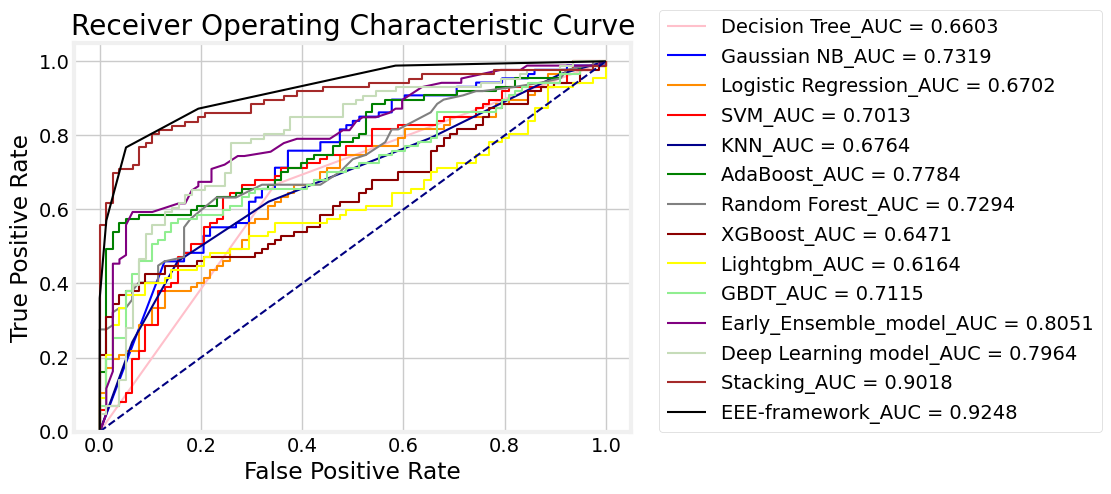

In [30]:
roc_auc_gnb_o = metrics.auc(fpr_gnb_o, tpr_gnb_o)
roc_auc_lr_o = metrics.auc(fpr_lr_o, tpr_lr_o)
roc_auc_svm_o = metrics.auc(fpr_svm_o, tpr_svm_o)
roc_auc_knn_o = metrics.auc(fpr_knn_o, tpr_knn_o)
roc_auc_ada_o= metrics.auc(fpr_ada_o, tpr_ada_o)
roc_auc_rf_o = metrics.auc(fpr_rf_o, tpr_rf_o)
roc_auc_dt_o = metrics.auc(fpr_dt_o, tpr_dt_o)
roc_auc_xgb_o = metrics.auc(fpr_xgb_o, tpr_xgb_o)
roc_auc_lgb_o = metrics.auc(fpr_lgb_o, tpr_lgb_o)
roc_auc_gbdt_o = metrics.auc(fpr_gbdt_o, tpr_gbdt_o)

roc_auc_early=metrics.auc(fpr_early,tpr_early)

roc_auc_stacking=metrics.auc(fpr_stacking,tpr_stacking)
roc_auc_voting = metrics.auc(fpr_voting, tpr_voting)
# 绘制AUC曲线
fig=plt.figure(facecolor='white')
ax = fig.add_subplot(111)
ax.patch.set_facecolor('white')
lw =1.5
plt.plot(fpr_dt_o, tpr_dt_o, color='pink',lw=lw, label='Decision Tree_AUC = %0.4f' % roc_auc_dt_o)
plt.plot(fpr_gnb_o, tpr_gnb_o, color='blue',lw=lw, label='Gaussian NB_AUC = %0.4f' % roc_auc_gnb_o)
plt.plot(fpr_lr_o, tpr_lr_o, color='darkorange', lw=lw, label='Logistic Regression_AUC = %0.4f' % roc_auc_lr_o)
plt.plot(fpr_svm_o, tpr_svm_o, color='red',lw=lw, label='SVM_AUC = %0.4f' % roc_auc_svm_o)
plt.plot(fpr_knn_o, tpr_knn_o, color='darkblue',lw=lw, label='KNN_AUC = %0.4f' % roc_auc_knn_o)
plt.plot(fpr_ada_o, tpr_ada_o, color='green',lw=lw, label='AdaBoost_AUC = %0.4f' % roc_auc_ada_o)
plt.plot(fpr_rf_o, tpr_rf_o, color='gray', lw=lw, label='Random Forest_AUC = %0.4f' % roc_auc_rf_o)
plt.plot(fpr_xgb_o, tpr_xgb_o, color='darkred',lw=lw, label='XGBoost_AUC = %0.4f' % roc_auc_xgb_o)
plt.plot(fpr_lgb_o, tpr_lgb_o, color='yellow',lw=lw, label='Lightgbm_AUC = %0.4f' % roc_auc_lgb_o)
plt.plot(fpr_gbdt_o, tpr_gbdt_o, color='lightgreen',lw=lw, label='GBDT_AUC = %0.4f' % roc_auc_gbdt_o)
plt.plot(fpr_early,tpr_early,color='purple',lw=lw,label='Early_Ensemble_model_AUC = %0.4f' % roc_auc_early)
plt.plot(fpr_deep, tpr_deep, color='#C6DCB9', lw=1.5, label='Deep Learning model_AUC = %0.4f' % roc_auc_deep)
plt.plot(fpr_stacking,tpr_stacking,color='brown',lw=lw, label='Stacking_AUC = %0.4f' % roc_auc_stacking)
plt.plot(fpr_voting, tpr_voting, color='black',lw=lw, label='EEE-framework_AUC = %0.4f' % roc_auc_voting)

plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
plt.xlim([-0.05, 1.05])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic Curve')
plt.legend(loc=(1.05,0),facecolor='white')
# plt.savefig('./auc-methy-14-yuan.jpg')
plt.show()

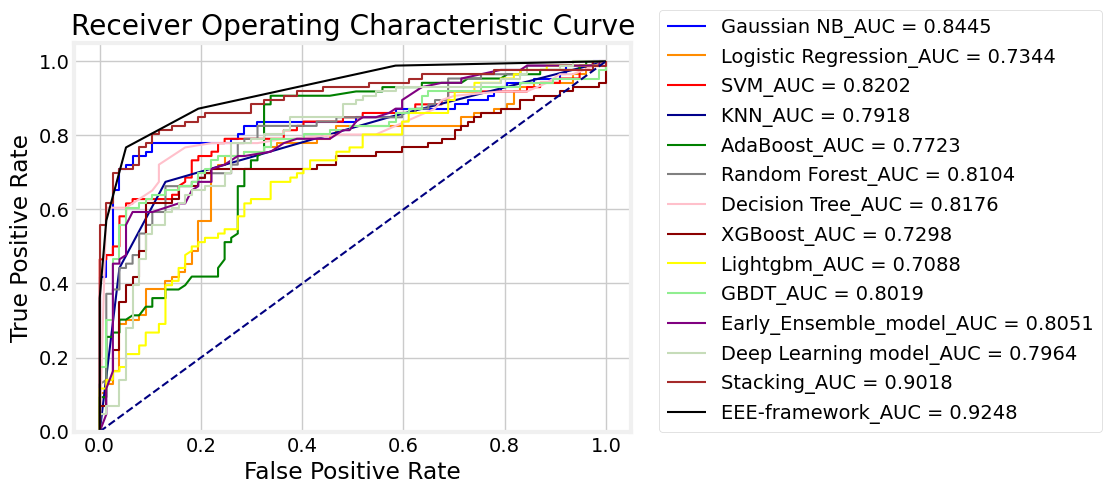

In [34]:
roc_auc_gnb = metrics.auc(fpr_gnb, tpr_gnb)
roc_auc_lr = metrics.auc(fpr_lr, tpr_lr)
roc_auc_svm = metrics.auc(fpr_svm, tpr_svm)
roc_auc_knn = metrics.auc(fpr_knn, tpr_knn)
roc_auc_ada= metrics.auc(fpr_ada, tpr_ada)
roc_auc_rf = metrics.auc(fpr_rf, tpr_rf)
roc_auc_dt = metrics.auc(fpr_dt, tpr_dt)
roc_auc_xgb = metrics.auc(fpr_xgb, tpr_xgb)
roc_auc_lgb = metrics.auc(fpr_lgb, tpr_lgb)
roc_auc_gbdt = metrics.auc(fpr_gbdt, tpr_gbdt)

roc_auc_early=metrics.auc(fpr_early,tpr_early)

roc_auc_stacking=metrics.auc(fpr_stacking,tpr_stacking)
roc_auc_voting = metrics.auc(fpr_voting, tpr_voting)
# 绘制AUC曲线
fig=plt.figure(facecolor='white')
ax = fig.add_subplot(111)
ax.patch.set_facecolor('white')
lw =1.5
plt.plot(fpr_gnb, tpr_gnb, color='blue',lw=lw, label='Gaussian NB_AUC = %0.4f' % roc_auc_gnb)
plt.plot(fpr_lr, tpr_lr, color='darkorange', lw=lw, label='Logistic Regression_AUC = %0.4f' % roc_auc_lr)
plt.plot(fpr_svm, tpr_svm, color='red',lw=lw, label='SVM_AUC = %0.4f' % roc_auc_svm)
plt.plot(fpr_knn, tpr_knn, color='darkblue',lw=lw, label='KNN_AUC = %0.4f' % roc_auc_knn)
plt.plot(fpr_ada, tpr_ada, color='green',lw=lw, label='AdaBoost_AUC = %0.4f' % roc_auc_ada)
plt.plot(fpr_rf, tpr_rf, color='gray', lw=lw, label='Random Forest_AUC = %0.4f' % roc_auc_rf)
plt.plot(fpr_dt, tpr_dt, color='pink',lw=lw, label='Decision Tree_AUC = %0.4f' % roc_auc_dt)
plt.plot(fpr_xgb, tpr_xgb, color='darkred',lw=lw, label='XGBoost_AUC = %0.4f' % roc_auc_xgb)
plt.plot(fpr_lgb, tpr_lgb, color='yellow',lw=lw, label='Lightgbm_AUC = %0.4f' % roc_auc_lgb)
plt.plot(fpr_gbdt, tpr_gbdt, color='lightgreen',lw=lw, label='GBDT_AUC = %0.4f' % roc_auc_gbdt)
plt.plot(fpr_early,tpr_early,color='purple',lw=lw,label='Early_Ensemble_model_AUC = %0.4f' % roc_auc_early)
plt.plot(fpr_deep, tpr_deep, color='#C6DCB9', lw=1.5, label='Deep Learning model_AUC = %0.4f' % roc_auc_deep)
plt.plot(fpr_stacking,tpr_stacking,color='brown',lw=lw, label='Stacking_AUC = %0.4f' % roc_auc_stacking)
plt.plot(fpr_voting, tpr_voting, color='black',lw=lw, label='EEE-framework_AUC = %0.4f' % roc_auc_voting)

plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
plt.xlim([-0.05, 1.05])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic Curve')
plt.legend(loc=(1.05,0),facecolor='white')
# plt.savefig('./auc-methy-14.jpg')
plt.show()

### 计算std、95%CI、P-value

In [31]:
acc_dt_o,pre_dt_o,rec_dt_o,f1_dt_o,e,y_dt_o,y_t_dt_o=crosspredict(yuan6,X_yuan,y_yuan,10)
acc_rf_o,pre_rf_o,rec_rf_o,f1_rf_o,e,y_rf_o,y_t_rf_o=crosspredict(yuan7,X_yuan,y_yuan,10)
acc_ada_o,pre_ada_o,rec_ada_o,f1_ada_o,e,y_ada_o,y_t_ada_o=crosspredict(yuan8,X_yuan,y_yuan,10)
acc_gbdt_o,pre_gbdt_o,rec_gbdt_o,f1_gbdt_o,e,y_gbdt_o,y_t_gbdt_o=crosspredict(yuan9,X_yuan,y_yuan,10)
acc_xgb_o,pre_xgb_o,rec_xgb_o,f1_xgb_o,e,y_xgb_o,y_t_xgb_o=crosspredict(yuan10,X_yuan,y_yuan,10)
acc_knn_o,pre_knn_o,rec_knn_o,f1_knn_o,e,y_knn_o,y_t_knn_o=crosspredict(yuan2,X_yuan,y_yuan,10)
acc_lgb_o,pre_lgb_o,rec_lgb_o,f1_lgb_o,e,y_lgb_o,y_t_lgb_o=crosspredict(yuan11,X_yuan,y_yuan,10)
acc_svm_o,pre_svm_o,rec_svm_o,f1_svm_o,e,y_svm_o,y_t_svm_o=crosspredict(yuan1,X_yuan,y_yuan,10)
acc_gnb_o,pre_gnb_o,rec_gnb_o,f1_gnb_o,e,y_gnb_o,y_t_gnb_o=crosspredict(yuan4,X_yuan,y_yuan,10)
acc_lr_o,pre_lr_o,rec_lr_o,f1_lr_o,e,y_lr_o,y_t_lr_o=crosspredict(yuan3,X_yuan,y_yuan,10)

acc_dt,pre_dt,rec_dt,f1_dt,e,y_dt,y_t_dt=crosspredict(model_dt_fs,X_pre,y,10)
acc_rf,pre_rf,rec_rf,f1_rf,e,y_rf,y_t_rf=crosspredict(model_rf_fs,X_pre,y,10)
acc_ada,pre_ada,rec_ada,f1_ada,e,y_ada,y_t_ada=crosspredict(model_ada_fs,X_pre,y,10)
acc_gbdt,pre_gbdt,rec_gbdt,f1_gbdt,e,y_gbdt,y_t_gbdt=crosspredict(model_gb_fs,X_pre,y,10)
acc_xgb,pre_xgb,rec_xgb,f1_xgb,e,y_xgb,y_t_xgb=crosspredict(model_xgb_fs,X_pre,y,10)
acc_knn,pre_knn,rec_knn,f1_knn,e,y_knn,y_t_knn=crosspredict(model_KN_fs,X_pre,y,10)
acc_lgb,pre_lgb,rec_lgb,f1_lgb,e,y_lgb,y_t_lgb=crosspredict(model_Lightgbm_fs,X_pre,y,10)
acc_svm,pre_svm,rec_svm,f1_svm,e,y_svm,y_t_svm=crosspredict(model_SVC_fs,X_pre,y,10)
acc_gnb,pre_gnb,rec_gnb,f1_gnb,e,y_gnb,y_t_gnb=crosspredict(model_GNB_fs,X_pre,y,10)
acc_lr,pre_lr,rec_lr,f1_lr,e,y_lr,y_t_lr=crosspredict(model_lr_fs,X_pre,y,10)

acc_early,pre_early,rec_early,f1_early,e,y_early,y_t_early=crosspredict(early,X_pre,y,10)
acc_stacking,pre_stacking,rec_stacking,f1_stacking,e,y_stacking,y_t_stacking=crosspredict(model_Stacking_cross,X_pre,y,10)
acc_voting,pre_voting,rec_voting,f1_voting,e,y_voting,y_t_voting=crosspredict(model_voting_hard,X_pre,y,10)

cross-validate across the entire data set
the confusion_matrix of the model is : 
 [[59 19]
 [29 58]]
the accuracy of the model is :  0.7090909090909091
the precision score of the model is :  0.7532467532467533
the recall score of the model is : 0.6666666666666666
the f1_score of the model  is : 0.7073170731707318
the weighted_f1 of the model is : 0.7089840515053563
the classification_report is :
               precision    recall  f1-score   support

           0     0.6705    0.7564    0.7108        78
           1     0.7532    0.6667    0.7073        87

    accuracy                         0.7091       165
   macro avg     0.7119    0.7115    0.7091       165
weighted avg     0.7141    0.7091    0.7090       165

cross-validate across the entire data set
the confusion_matrix of the model is : 
 [[57 21]
 [32 55]]
the accuracy of the model is :  0.6787878787878788
the precision score of the model is :  0.7236842105263158
the recall score of the model is : 0.632183908045977
the f1_s

In [35]:
# 创建数据
data_model_24 = {
    'Accuracy': [acc_dt_o, acc_dt,
                 acc_svm_o,acc_svm, 
                 acc_knn_o,acc_knn,
                 acc_lr_o,acc_lr,
                 acc_gnb_o,acc_gnb,
                 acc_rf_o,acc_rf,
                 acc_ada_o,acc_ada,
                 acc_gbdt_o,acc_gbdt,
                 acc_xgb_o,acc_xgb,
                 acc_lgb_o,acc_lgb,
                 acc_early,overall_accuracy_deep,acc_stacking,acc_voting],
    'Precision': [pre_dt_o,pre_dt, 
                  pre_svm_o,pre_svm, 
                  pre_knn_o, pre_knn,
                  pre_lr_o, pre_lr,
                  pre_gnb_o, pre_gnb,
                  pre_rf_o, pre_rf,
                  pre_ada_o,pre_ada,
                  pre_gbdt_o,pre_gbdt, 
                  pre_xgb_o,pre_xgb, 
                  pre_lgb_o,pre_lgb, 
                  pre_early, overall_precision_deep, pre_stacking, pre_voting],
    'Recall': [rec_dt_o, rec_dt,
               rec_svm_o,rec_svm, 
               rec_knn_o, rec_knn,
               rec_lr_o, rec_lr,
               rec_gnb_o,rec_gnb, 
               rec_rf_o, rec_rf,
               rec_ada_o,rec_ada,
               rec_gbdt_o,rec_gbdt, 
               rec_xgb_o,rec_xgb, 
               rec_lgb_o, rec_lgb,
               rec_early, overall_recall_deep, rec_stacking, rec_voting],
    'F1_score':[f1_dt_o,f1_dt, 
                f1_svm_o,f1_svm, 
                f1_knn_o,f1_knn, 
                f1_lr_o,f1_lr, 
                f1_gnb_o, f1_gnb,
                f1_rf_o,f1_rf, 
                f1_ada_o, f1_ada,
                f1_gbdt_o,f1_gbdt, 
                f1_xgb_o,f1_xgb, 
                f1_lgb_o,f1_lgb, 
                f1_early, overall_f1_deep, f1_stacking, f1_voting],
    'AUC':[roc_auc_dt_o,roc_auc_dt,
           roc_auc_svm_o,roc_auc_svm,
           roc_auc_knn_o,roc_auc_knn,
           roc_auc_lr_o,roc_auc_lr,
           roc_auc_gnb_o,roc_auc_gnb,
           roc_auc_rf_o,roc_auc_rf,
           roc_auc_ada_o,roc_auc_ada,
           roc_auc_gbdt_o,roc_auc_gbdt,
           roc_auc_xgb_o,roc_auc_xgb,
           roc_auc_lgb_o,roc_auc_lgb,
           roc_auc_early,roc_auc_deep,roc_auc_stacking,roc_auc_voting]
}
index_24 = ['Decision Tree', 'Decision Tree+',
             'SVM', 'SVM+',
             'KNN','KNN+',
             'Logistic Regression','Logistic Regression+',
             'Gaussian NB','Gaussian NB+',
             'Random Forest','Random Forest+',
             'AdaBoost','AdaBoost+',
             'GBDT','GBDT+',
             'XGBoost','XGBoost+',
             'Lightgbm','Lightgbm+',
             'Early Ensemble',
             'Deep Learning',
             'Stacking',
             'Our EEE-framework',]

# 创建DataFrame
df_model_24= pd.DataFrame(data_model_24, index=index_24)
pd.set_option('display.float_format', lambda x: '%.4f' % x)

In [37]:
# 创建数据
data_model_std_24 = {
    'Accuracy': [data9_acc.std(), data10_acc.std(),
                 data1_acc.std(), data2_acc.std(),
                 data3_acc.std(), data4_acc.std(),
                 data5_acc.std(), data6_acc.std(),
                 data7_acc.std(), data8_acc.std(),
                 data11_acc.std(), data12_acc.std(),
                 data13_acc.std(), data14_acc.std(),
                 data15_acc.std(), data16_acc.std(),
                 data17_acc.std(), data18_acc.std(),
                 data19_acc.std(), data20_acc.std(),
                 data21_acc.std(), data22_acc.std(), data23_acc.std(), data24_acc.std()],
    'Precision': [data9_pre.std(), data10_pre.std(), 
                  data1_pre.std(), data2_pre.std(), 
                  data3_pre.std(), data4_pre.std(), 
                  data5_pre.std(), data6_pre.std(), 
                  data7_pre.std(), data8_pre.std(), 
                  data11_pre.std(), data12_pre.std(), 
                  data13_pre.std(), data14_pre.std(), 
                  data15_pre.std(), data16_pre.std(), 
                  data17_pre.std(), data18_pre.std(), 
                  data19_pre.std(), data20_pre.std(), 
                  data21_pre.std(), data22_pre.std(), data23_pre.std(), data24_pre.std()],
    'Recall': [data9_rec.std(), data10_rec.std(),
               data1_rec.std(), data2_rec.std(),
               data3_rec.std(), data4_rec.std(),
               data5_rec.std(), data6_rec.std(),
               data7_rec.std(), data8_rec.std(),
               data11_rec.std(), data12_rec.std(),
               data13_rec.std(), data14_rec.std(),
               data15_rec.std(), data16_rec.std(),
               data17_rec.std(), data18_rec.std(),
               data19_rec.std(), data20_rec.std(),
               data21_rec.std(), data22_rec.std(), data23_rec.std(), data24_rec.std()],
    'F1_score': [data9_f1.std(), data10_f1.std(), 
                 data1_f1.std(), data2_f1.std(), 
                 data3_f1.std(), data4_f1.std(), 
                 data5_f1.std(), data6_f1.std(), 
                 data7_f1.std(), data7_f1.std(), 
                 data11_f1.std(), data12_f1.std(), 
                 data13_f1.std(), data14_f1.std(), 
                 data15_f1.std(), data16_f1.std(), 
                 data17_f1.std(), data18_f1.std(), 
                 data19_f1.std(), data20_f1.std(), 
                 data21_f1.std(), data22_f1.std(), data23_f1.std(), data24_f1.std()],
    'AUC':[data9_auc.std(), data10_auc.std(), 
           data1_auc.std(), data2_auc.std(), 
           data3_auc.std(), data4_auc.std(), 
           data5_auc.std(), data6_auc.std(), 
           data7_auc.std(), data8_auc.std(), 
           data11_auc.std(), data12_auc.std(), 
           data13_auc.std(), data14_auc.std(), 
           data15_auc.std(), data16_auc.std(), 
           data17_auc.std(), data18_auc.std(), 
           data19_auc.std(), data20_auc.std(), 
           data21_auc.std(), data22_auc.std(), data23_auc.std(), data24_auc.std()]
}
index_std_24 = ['Decision Tree', 'Decision Tree+',
             'SVM', 'SVM+',
             'KNN','KNN+',
             'Logistic Regression','Logistic Regression+',
             'Gaussian NB','Gaussian NB+',
             'Random Forest','Random Forest+',
             'AdaBoost','AdaBoost+',
             'GBDT','GBDT+',
             'XGBoost','XGBoost+',
             'Lightgbm','Lightgbm+',
             'Early Ensemble',
             'Deep Learning',
             'Stacking',
             'Our EEE-framework']

# 创建DataFrame
df_model_std_24= pd.DataFrame(data_model_std_24, index=index_std_24)
pd.set_option('display.float_format', lambda x: '%.4f' % x)

In [39]:
def calculate_confidence_interval(data, confidence_level=0.95):
    """
    计算置信区间
    :param data: 样本数据（列表或numpy数组）
    :param confidence_level: 置信水平（默认为0.95）
    :return: 置信区间（下限，上限）
    """
    # 计算样本均值
    mean = np.mean(data)
    
    # 计算样本标准差
    std_err = np.std(data, ddof=1) / np.sqrt(len(data))
    
    # 计算自由度
    df = len(data) - 1
    
    # 计算置信区间
    interval = stats.t.interval(confidence_level, df, loc=mean, scale=std_err)
    
    return interval

In [40]:
data_model_interval_24 = {
    'Accuracy': [calculate_confidence_interval(data9_acc), calculate_confidence_interval(data10_acc),
                 calculate_confidence_interval(data1_acc), calculate_confidence_interval(data2_acc),
                 calculate_confidence_interval(data3_acc), calculate_confidence_interval(data4_acc),
                 calculate_confidence_interval(data5_acc), calculate_confidence_interval(data6_acc),
                 calculate_confidence_interval(data7_acc), calculate_confidence_interval(data8_acc),
                 calculate_confidence_interval(data11_acc), calculate_confidence_interval(data12_acc),
                 calculate_confidence_interval(data13_acc), calculate_confidence_interval(data14_acc),
                 calculate_confidence_interval(data15_acc), calculate_confidence_interval(data16_acc),
                 calculate_confidence_interval(data17_acc), calculate_confidence_interval(data18_acc),
                 calculate_confidence_interval(data19_acc), calculate_confidence_interval(data20_acc),
                 calculate_confidence_interval(data21_acc), 
                 calculate_confidence_interval(data22_acc), 
                 calculate_confidence_interval(data23_acc), 
                 calculate_confidence_interval(data24_acc)],
    'Precision': [calculate_confidence_interval(data9_pre), calculate_confidence_interval(data10_pre),
                  calculate_confidence_interval(data1_pre), calculate_confidence_interval(data2_pre),
                  calculate_confidence_interval(data3_pre), calculate_confidence_interval(data4_pre),
                  calculate_confidence_interval(data5_pre), calculate_confidence_interval(data6_pre),
                  calculate_confidence_interval(data7_pre), calculate_confidence_interval(data8_pre),
                  calculate_confidence_interval(data11_pre), calculate_confidence_interval(data12_pre),
                  calculate_confidence_interval(data13_pre), calculate_confidence_interval(data14_pre),
                  calculate_confidence_interval(data15_pre), calculate_confidence_interval(data16_pre),
                  calculate_confidence_interval(data17_pre), calculate_confidence_interval(data18_pre),
                  calculate_confidence_interval(data19_pre), calculate_confidence_interval(data20_pre),
                  calculate_confidence_interval(data21_pre), 
                  calculate_confidence_interval(data22_pre), 
                  calculate_confidence_interval(data23_pre), 
                  calculate_confidence_interval(data24_pre)],
    'Recall': [calculate_confidence_interval(data9_rec), calculate_confidence_interval(data10_rec), 
               calculate_confidence_interval(data1_rec), calculate_confidence_interval(data2_rec), 
               calculate_confidence_interval(data3_rec), calculate_confidence_interval(data4_rec), 
               calculate_confidence_interval(data5_rec), calculate_confidence_interval(data6_rec), 
               calculate_confidence_interval(data7_rec), calculate_confidence_interval(data8_rec), 
               calculate_confidence_interval(data11_rec), calculate_confidence_interval(data12_rec), 
               calculate_confidence_interval(data13_rec), calculate_confidence_interval(data14_rec), 
               calculate_confidence_interval(data15_rec), calculate_confidence_interval(data16_rec), 
               calculate_confidence_interval(data17_rec), calculate_confidence_interval(data18_rec), 
               calculate_confidence_interval(data19_rec), calculate_confidence_interval(data20_rec), 
               calculate_confidence_interval(data21_rec), 
               calculate_confidence_interval(data22_rec), 
               calculate_confidence_interval(data23_rec), 
               calculate_confidence_interval(data24_rec)],
    'F1_score': [calculate_confidence_interval(data9_f1), calculate_confidence_interval(data10_f1),
                 calculate_confidence_interval(data1_f1), calculate_confidence_interval(data2_f1),
                 calculate_confidence_interval(data3_f1), calculate_confidence_interval(data4_f1),
                 calculate_confidence_interval(data5_f1), calculate_confidence_interval(data6_f1),
                 calculate_confidence_interval(data7_f1), calculate_confidence_interval(data8_f1),
                 calculate_confidence_interval(data11_f1), calculate_confidence_interval(data12_f1),
                 calculate_confidence_interval(data13_f1), calculate_confidence_interval(data14_f1),
                 calculate_confidence_interval(data15_f1), calculate_confidence_interval(data16_f1),
                 calculate_confidence_interval(data17_f1), calculate_confidence_interval(data18_f1),
                 calculate_confidence_interval(data19_f1), calculate_confidence_interval(data20_f1),
                 calculate_confidence_interval(data21_f1), 
                 calculate_confidence_interval(data22_f1), 
                 calculate_confidence_interval(data23_f1), 
                 calculate_confidence_interval(data24_f1)],
    'AUC':[calculate_confidence_interval(data9_auc), calculate_confidence_interval(data10_auc), 
           calculate_confidence_interval(data1_auc), calculate_confidence_interval(data2_auc), 
            calculate_confidence_interval(data3_auc), calculate_confidence_interval(data4_auc), 
           calculate_confidence_interval(data5_auc), calculate_confidence_interval(data6_auc), 
            calculate_confidence_interval(data7_auc), calculate_confidence_interval(data8_auc), 
           calculate_confidence_interval(data11_auc), calculate_confidence_interval(data12_auc), 
            calculate_confidence_interval(data13_auc), calculate_confidence_interval(data14_auc), 
           calculate_confidence_interval(data15_auc), calculate_confidence_interval(data16_auc), 
            calculate_confidence_interval(data17_auc), calculate_confidence_interval(data18_auc), 
           calculate_confidence_interval(data19_auc), calculate_confidence_interval(data20_auc), 
            calculate_confidence_interval(data21_auc), 
           calculate_confidence_interval(data22_auc), 
            calculate_confidence_interval(data23_auc), 
           calculate_confidence_interval(data24_auc)]
}
index_interval_24 = ['Decision Tree', 'Decision Tree+',
             'SVM', 'SVM+',
             'KNN','KNN+',
             'Logistic Regression','Logistic Regression+',
             'Gaussian NB','Gaussian NB+',
             'Random Forest','Random Forest+',
             'AdaBoost','AdaBoost+',
             'GBDT','GBDT+',
             'XGBoost','XGBoost+',
             'Lightgbm','Lightgbm+',
             'Early Ensemble',
             'Deep Learning',
             'Stacking',
             'Our EEE-framework']

# 创建DataFrame
df_model_interval_24= pd.DataFrame(data_model_interval_24, index=index_interval_24)
pd.set_option('display.float_format', lambda x: '%.4f' % x)

In [42]:
def zhengtai(datazhengtai):
    
    shapiro_result = stats.shapiro(datazhengtai)
    print("Shapiro-Wilk Test:")
    print(f"Statistic: {shapiro_result.statistic}, p-value: {shapiro_result.pvalue}")
    
    # 判断是否正态
    if shapiro_result.pvalue > 0.05:
        print("数据符合正态分布")
        return 1
    else:
        print("数据不符合正态分布")
        return 0

nowacc = [data1_acc, data2_acc, data3_acc, data4_acc, data5_acc, data6_acc, data7_acc, data8_acc, data9_acc, data10_acc, data11_acc, data12_acc, data13_acc, data14_acc, data15_acc, data16_acc, data17_acc, data18_acc, data19_acc, data20_acc, data21_acc, data22_acc, data23_acc, data24_acc]

nowpre = [data1_pre, data2_pre, data3_pre, data4_pre, data5_pre, data6_pre, data7_pre, data8_pre, data9_pre, data10_pre, data11_pre, data12_pre, data13_pre, data14_pre, data15_pre, data16_pre, data17_pre, data18_pre, data19_pre, data20_pre, data21_pre, data22_pre, data23_pre, data24_pre]

nowrec = [data1_rec, data2_rec, data3_rec, data4_rec, data5_rec, data6_rec, data7_rec, data8_rec, data9_rec, data10_rec, data11_rec, data12_rec, data13_rec, data14_rec, data15_rec, data16_rec, data17_rec, data18_rec, data19_rec, data20_rec, data21_rec, data22_rec, data23_rec, data24_rec]

nowf1 = [data1_f1, data2_f1, data3_f1, data4_f1, data5_f1, data6_f1, data7_f1, data8_f1, data9_f1, data10_f1, data11_f1, data12_f1, data13_f1, data14_f1, data15_f1, data16_f1, data17_f1, data18_f1, data19_f1, data20_f1, data21_f1, data22_f1, data23_f1, data24_f1]

nowauc = [data1_auc, data2_auc, data3_auc, data4_auc, data5_auc, data6_auc, data7_auc, data8_auc, data9_auc, data10_auc, data11_auc, data12_auc, data13_auc, data14_auc, data15_auc, data16_auc, data17_auc, data18_auc, data19_auc, data20_auc, data21_auc, data22_auc, data23_auc, data24_auc]
acct=[]
pret=[]
rect=[]
f1t=[]
auct=[]
for i in range(24):
    acct.append(zhengtai(nowacc[i]))

for i in range(24):
    pret.append(zhengtai(nowpre[i]))

for i in range(24):
    rect.append(zhengtai(nowrec[i]))

for i in range(24):
    f1t.append(zhengtai(nowf1[i]))

for i in range(24):
    auct.append(zhengtai(nowauc[i]))

Shapiro-Wilk Test:
Statistic: 0.947610861271934, p-value: 0.6403273610347214
数据符合正态分布
Shapiro-Wilk Test:
Statistic: 0.9631584860757706, p-value: 0.8211991346606814
数据符合正态分布
Shapiro-Wilk Test:
Statistic: 0.8971891898044833, p-value: 0.20400932127794413
数据符合正态分布
Shapiro-Wilk Test:
Statistic: 0.8611649809700352, p-value: 0.07875977977310779
数据符合正态分布
Shapiro-Wilk Test:
Statistic: 0.9356597640593798, p-value: 0.5058026211423029
数据符合正态分布
Shapiro-Wilk Test:
Statistic: 0.9496525624450403, p-value: 0.6643914756789384
数据符合正态分布
Shapiro-Wilk Test:
Statistic: 0.9281231430824077, p-value: 0.42968728228681685
数据符合正态分布
Shapiro-Wilk Test:
Statistic: 0.8908330589871025, p-value: 0.17327634494055327
数据符合正态分布
Shapiro-Wilk Test:
Statistic: 0.9635417773728072, p-value: 0.8253775573359496
数据符合正态分布
Shapiro-Wilk Test:
Statistic: 0.9694549313142438, p-value: 0.8857459499259217
数据符合正态分布
Shapiro-Wilk Test:
Statistic: 0.9582125729836869, p-value: 0.7653146205905081
数据符合正态分布
Shapiro-Wilk Test:
Statistic: 0.93798207

In [43]:
for i in range(24):
    if acct[i]==0:
        print(i+1)

13
18
19
20


In [45]:
import numpy as np
from scipy.stats import ttest_ind

# 定义一个函数来计算右尾T检验的p值
def right_tailed_ttest(sample1, sample2, equal_var=False):
    t_statistic, p_value_two_tailed = ttest_ind(sample1, sample2, equal_var=equal_var)
    # 右尾检验：如果 t 统计量为正，支持 H1: μ1 > μ2
    if t_statistic > 0:  # t 统计量为正，支持备择假设
        p_value_one_tailed = p_value_two_tailed / 2
    else:
        p_value_one_tailed = 1  # 如果 t 统计量为负，不支持备择假设
    return t_statistic, p_value_one_tailed

import numpy as np
from scipy.stats import mannwhitneyu

# 定义一个函数来计算右尾 Mann-Whitney U 检验的 p 值
def right_tailed_mannwhitneyu_test(sample1, sample2):
    u_statistic, p_value_two_tailed = mannwhitneyu(sample1, sample2, alternative='greater')
    return u_statistic, p_value_two_tailed

# 使用 Accuracy 数据进行右尾 T 检验
# 删除对基础模型自身的检验，因为没有意义
t_statistic, p_value_acc_1 = right_tailed_ttest(data1_acc, data9_acc, equal_var=False)
print("svc:", p_value_acc_1)

t_statistic, p_value_acc_5 = right_tailed_ttest(data5_acc, data9_acc, equal_var=False)
print("lr:", p_value_acc_5)

t_statistic, p_value_acc_7 = right_tailed_ttest(data7_acc, data9_acc, equal_var=False)
print("gnb:", p_value_acc_7)

t_statistic, p_value_acc_3 = right_tailed_ttest(data3_acc, data9_acc, equal_var=False)
print("knn:", p_value_acc_3)

t_statistic, p_value_acc_11 = right_tailed_ttest(data11_acc, data9_acc, equal_var=False)
print("rf:", p_value_acc_11)

# t_statistic, p_value_acc_13 = right_tailed_ttest(data13_acc, data9_acc, equal_var=False)
# print("ada:", p_value_acc_13)
u_statistic, p_value_acc_13 = right_tailed_mannwhitneyu_test(data13_acc, data9_acc)
print("ada:", p_value_acc_13)

t_statistic, p_value_acc_15 = right_tailed_ttest(data15_acc, data9_acc, equal_var=False)
print("gbdt:", p_value_acc_15)

t_statistic, p_value_acc_17 = right_tailed_ttest(data17_acc, data9_acc, equal_var=False)
print("xgb:", p_value_acc_17)

# t_statistic, p_value_acc_19 = right_tailed_ttest(data19_acc, data9_acc, equal_var=False)
# print("lgb:", p_value_acc_19)

u_statistic, p_value_acc_19 = right_tailed_mannwhitneyu_test(data19_acc, data9_acc)
print("lgb:", p_value_acc_19)

t_statistic, p_value_acc_2 = right_tailed_ttest(data2_acc, data9_acc, equal_var=False)
print("svc+:", p_value_acc_2)

t_statistic, p_value_acc_6 = right_tailed_ttest(data6_acc, data9_acc, equal_var=False)
print("lr+:", p_value_acc_6)

t_statistic, p_value_acc_8 = right_tailed_ttest(data8_acc, data9_acc, equal_var=False)
print("gnb+:", p_value_acc_8)

t_statistic, p_value_acc_4 = right_tailed_ttest(data4_acc, data9_acc, equal_var=False)
print("knn+:", p_value_acc_4)

t_statistic, p_value_acc_10 = right_tailed_ttest(data10_acc, data9_acc, equal_var=False)
print("dt+:", p_value_acc_10)

t_statistic, p_value_acc_12 = right_tailed_ttest(data12_acc, data9_acc, equal_var=False)
print("rf+:", p_value_acc_12)

t_statistic, p_value_acc_14 = right_tailed_ttest(data14_acc, data9_acc, equal_var=False)
print("ada+:", p_value_acc_14)

t_statistic, p_value_acc_16 = right_tailed_ttest(data16_acc, data9_acc, equal_var=False)
print("gbdt+:", p_value_acc_16)

# t_statistic, p_value_acc_18 = right_tailed_ttest(data18_acc, data9_acc, equal_var=False)
# print("xgb+:", p_value_acc_18)
u_statistic, p_value_acc_18 = right_tailed_mannwhitneyu_test(data18_acc, data9_acc)
print("xgb+:", p_value_acc_18)

# t_statistic, p_value_acc_20 = right_tailed_ttest(data20_acc, data9_acc, equal_var=False)
# print("lgb+:", p_value_acc_20)
u_statistic, p_value_acc_20 = right_tailed_mannwhitneyu_test(data20_acc, data9_acc)
print("lgb+:", p_value_acc_20)

t_statistic, p_value_acc_21 = right_tailed_ttest(data21_acc, data9_acc, equal_var=False)
print("early:", p_value_acc_21)

t_statistic, p_value_acc_22 = right_tailed_ttest(data22_acc, data9_acc, equal_var=False)
print("deep:", p_value_acc_22)

t_statistic, p_value_acc_23 = right_tailed_ttest(data23_acc, data9_acc, equal_var=False)
print("stacking:", p_value_acc_23)

t_statistic, p_value_acc_24 = right_tailed_ttest(data24_acc, data9_acc, equal_var=False)
print("voting:", p_value_acc_24)


svc: 1
lr: 1
gnb: 1
knn: 1
rf: 1
ada: 0.29702686518756394
gbdt: 1
xgb: 1
lgb: 0.9485961690868546
svc+: 0.00023689097410001337
lr+: 0.03476832102550771
gnb+: 0.00461770896862892
knn+: 0.0006519163946631373
dt+: 0.0014554718507347366
rf+: 0.062312149803796214
ada+: 0.03831375845988463
gbdt+: 0.048121472772525216
xgb+: 0.023661830408816382
lgb+: 0.742773686542618
early: 0.2205349345457373
deep: 1
stacking: 4.696557453694314e-05
voting: 0.00027210294829759586


In [46]:
for i in range(24):
    if pret[i]==0:
        print(i+1)

2
4
8
23
24


In [47]:
import numpy as np
from scipy.stats import ttest_ind

# 定义一个函数来计算右尾T检验的p值
def right_tailed_ttest(sample1, sample2, equal_var=False):
    t_statistic, p_value_two_tailed = ttest_ind(sample1, sample2, equal_var=equal_var)
    # 右尾检验：如果 t 统计量为正，支持 H1: μ1 > μ2
    if t_statistic > 0:  # t 统计量为正，支持备择假设
        p_value_one_tailed = p_value_two_tailed / 2
    else:
        p_value_one_tailed = 1  # 如果 t 统计量为负，不支持备择假设
    return t_statistic, p_value_one_tailed

import numpy as np
from scipy.stats import mannwhitneyu

# 定义一个函数来计算右尾 Mann-Whitney U 检验的 p 值
def right_tailed_mannwhitneyu_test(sample1, sample2):
    u_statistic, p_value_two_tailed = mannwhitneyu(sample1, sample2, alternative='greater')
    return u_statistic, p_value_two_tailed

# 使用 Precision 数据进行右尾 T 检验
# 删除对基础模型自身的检验，因为没有意义
t_statistic, p_value_pre_1 = right_tailed_ttest(data1_pre, data9_pre, equal_var=False)
print("svc:", p_value_pre_1)

t_statistic, p_value_pre_5 = right_tailed_ttest(data5_pre, data9_pre, equal_var=False)
print("lr:", p_value_pre_5)

t_statistic, p_value_pre_7 = right_tailed_ttest(data7_pre, data9_pre, equal_var=False)
print("gnb:", p_value_pre_7)

t_statistic, p_value_pre_3 = right_tailed_ttest(data3_pre, data9_pre, equal_var=False)
print("knn:", p_value_pre_3)

t_statistic, p_value_pre_11 = right_tailed_ttest(data11_pre, data9_pre, equal_var=False)
print("rf:", p_value_pre_11)

t_statistic, p_value_pre_13 = right_tailed_ttest(data13_pre, data9_pre, equal_var=False)
print("ada:", p_value_pre_13)

t_statistic, p_value_pre_15 = right_tailed_ttest(data15_pre, data9_pre, equal_var=False)
print("gbdt:", p_value_pre_15)

t_statistic, p_value_pre_17 = right_tailed_ttest(data17_pre, data9_pre, equal_var=False)
print("xgb:", p_value_pre_17)

t_statistic, p_value_pre_19 = right_tailed_ttest(data19_pre, data9_pre, equal_var=False)
print("lgb:", p_value_pre_19)

# t_statistic, p_value_pre_2 = right_tailed_ttest(data2_pre, data9_pre, equal_var=False)
# print("svc+:", p_value_pre_2)
u_statistic, p_value_pre_2 = right_tailed_mannwhitneyu_test(data2_pre, data9_pre)
print("svc+:", p_value_pre_2)

t_statistic, p_value_pre_6 = right_tailed_ttest(data6_pre, data9_pre, equal_var=False)
print("lr+:", p_value_pre_6)

# t_statistic, p_value_pre_8 = right_tailed_ttest(data8_pre, data9_pre, equal_var=False)
# print("gnb+:", p_value_pre_8)
u_statistic, p_value_pre_8 = right_tailed_mannwhitneyu_test(data8_pre, data9_pre)
print("gnb+:", p_value_pre_8)

# t_statistic, p_value_pre_4 = right_tailed_ttest(data4_pre, data9_pre, equal_var=False)
# print("knn+:", p_value_pre_4)
u_statistic, p_value_pre_4 = right_tailed_mannwhitneyu_test(data4_pre, data9_pre)
print("knn+:", p_value_pre_4)

t_statistic, p_value_pre_10 = right_tailed_ttest(data10_pre, data9_pre, equal_var=False)
print("dt+:", p_value_pre_10)

t_statistic, p_value_pre_12 = right_tailed_ttest(data12_pre, data9_pre, equal_var=False)
print("rf+:", p_value_pre_12)

t_statistic, p_value_pre_14 = right_tailed_ttest(data14_pre, data9_pre, equal_var=False)
print("ada+:", p_value_pre_14)

t_statistic, p_value_pre_16 = right_tailed_ttest(data16_pre, data9_pre, equal_var=False)
print("gbdt+:", p_value_pre_16)

t_statistic, p_value_pre_18 = right_tailed_ttest(data18_pre, data9_pre, equal_var=False)
print("xgb+:", p_value_pre_18)

t_statistic, p_value_pre_20 = right_tailed_ttest(data20_pre, data9_pre, equal_var=False)
print("lgb+:", p_value_pre_20)

t_statistic, p_value_pre_21 = right_tailed_ttest(data21_pre, data9_pre, equal_var=False)
print("early:", p_value_pre_21)

t_statistic, p_value_pre_22 = right_tailed_ttest(data22_pre, data9_pre, equal_var=False)
print("deep:", p_value_pre_22)

# t_statistic, p_value_pre_23 = right_tailed_ttest(data23_pre, data9_pre, equal_var=False)
# print("stacking:", p_value_pre_23)
u_statistic, p_value_pre_23= right_tailed_mannwhitneyu_test(data23_pre, data9_pre)
print("stacking:", p_value_pre_23)

# t_statistic, p_value_pre_24 = right_tailed_ttest(data24_pre, data9_pre, equal_var=False)
# print("voting:", p_value_pre_24)
u_statistic, p_value_pre_24 = right_tailed_mannwhitneyu_test(data24_pre, data9_pre)
print("voting:", p_value_pre_24)

svc: 0.23967687104571167
lr: 1
gnb: 0.4959576431598274
knn: 1
rf: 1
ada: 0.4982690723911648
gbdt: 1
xgb: 1
lgb: 1
svc+: 0.0006010828375776502
lr+: 0.16646064077960954
gnb+: 0.0012616652221300207
knn+: 0.000998433276441516
dt+: 0.00138105999627254
rf+: 0.0559920462369943
ada+: 0.3391588548452793
gbdt+: 0.04324995212369785
xgb+: 0.016090964920313203
lgb+: 1
early: 0.2059148848937638
deep: 1
stacking: 0.00047816849267931743
voting: 0.00020503794305760185


In [48]:
for i in range(24):
    if rect[i]==0:
        print(i+1)

21
22


In [50]:
from scipy.stats import ttest_ind, mannwhitneyu

# 定义一个函数来计算右尾T检验的p值
def right_tailed_ttest(sample1, sample2, equal_var=False):
    t_statistic, p_value_two_tailed = ttest_ind(sample1, sample2, equal_var=equal_var)
    # 右尾检验：如果 t 统计量为正，支持 H1: μ1 > μ2
    if t_statistic > 0:  # t 统计量为正，支持备择假设
        p_value_one_tailed = p_value_two_tailed / 2
    else:
        p_value_one_tailed = 1  # 如果 t 统计量为负，不支持备择假设
    return t_statistic, p_value_one_tailed

# 定义一个函数来计算右尾U检验的p值
def right_tailed_utest(sample1, sample2):
    u_statistic, p_value_two_tailed = mannwhitneyu(sample1, sample2, alternative='greater')
    return u_statistic, p_value_two_tailed

# 使用 Recall 数据进行右尾 T 检验
# 删除对基础模型自身的检验，因为没有意义
t_statistic, p_value_rec_1 = right_tailed_ttest(data1_rec, data9_rec, equal_var=False)
print("svc:", p_value_rec_1)

t_statistic, p_value_rec_5 = right_tailed_ttest(data5_rec, data9_rec, equal_var=False)
print("lr:", p_value_rec_5)

t_statistic, p_value_rec_7 = right_tailed_ttest(data7_rec, data9_rec, equal_var=False)
print("gnb:", p_value_rec_7)

t_statistic, p_value_rec_3 = right_tailed_ttest(data3_rec, data9_rec, equal_var=False)
print("knn:", p_value_rec_3)

t_statistic, p_value_rec_11 = right_tailed_ttest(data11_rec, data9_rec, equal_var=False)
print("rf:", p_value_rec_11)

t_statistic, p_value_rec_13 = right_tailed_ttest(data13_rec, data9_rec, equal_var=False)
print("ada:", p_value_rec_13)

t_statistic, p_value_rec_15 = right_tailed_ttest(data15_rec, data9_rec, equal_var=False)
print("gbdt:", p_value_rec_15)

t_statistic, p_value_rec_17 = right_tailed_ttest(data17_rec, data9_rec, equal_var=False)
print("xgb:", p_value_rec_17)

# t_statistic, p_value_rec_19 = right_tailed_ttest(data19_rec, data9_rec, equal_var=False)
# print("lgb:", p_value_rec_19)

t_statistic, p_value_rec_2 = right_tailed_ttest(data2_rec, data9_rec, equal_var=False)
print("svc+:", p_value_rec_2)

t_statistic, p_value_rec_6 = right_tailed_ttest(data6_rec, data9_rec, equal_var=False)
print("lr+:", p_value_rec_6)

t_statistic, p_value_rec_8 = right_tailed_ttest(data8_rec, data9_rec, equal_var=False)
print("gnb+:", p_value_rec_8)

t_statistic, p_value_rec_4 = right_tailed_ttest(data4_rec, data9_rec, equal_var=False)
print("knn+:", p_value_rec_4)

t_statistic, p_value_rec_10 = right_tailed_ttest(data10_rec, data9_rec, equal_var=False)
print("dt+:", p_value_rec_10)

t_statistic, p_value_rec_12 = right_tailed_ttest(data12_rec, data9_rec, equal_var=False)
print("rf+:", p_value_rec_12)

t_statistic, p_value_rec_14 = right_tailed_ttest(data14_rec, data9_rec, equal_var=False)
print("ada+:", p_value_rec_14)

t_statistic, p_value_rec_16 = right_tailed_ttest(data16_rec, data9_rec, equal_var=False)
print("gbdt+:", p_value_rec_16)

t_statistic, p_value_rec_18 = right_tailed_ttest(data18_rec, data9_rec, equal_var=False)
print("xgb+:", p_value_rec_18)

t_statistic, p_value_rec_20 = right_tailed_ttest(data20_rec, data9_rec, equal_var=False)
print("lgb+:", p_value_rec_20)

# 对第21和第22个样本使用U检验
t_statistic, p_value_rec_19 = right_tailed_ttest(data19_rec, data9_rec, equal_var=False)
print("lgb:", p_value_rec_19)

u_statistic, p_value_rec_21 = right_tailed_utest(data21_rec, data9_rec)
print("early:", p_value_rec_21)

u_statistic, p_value_rec_22 = right_tailed_utest(data22_rec, data9_rec)
print("deep:", p_value_rec_22)

t_statistic, p_value_rec_23 = right_tailed_ttest(data23_rec, data9_rec, equal_var=False)
print("stacking:", p_value_rec_23)

t_statistic, p_value_rec_24 = right_tailed_ttest(data24_rec, data9_rec, equal_var=False)
print("voting:", p_value_rec_24)

svc: 1
lr: 0.24384115139244888
gnb: 1
knn: 1
rf: 0.44999406561960675
ada: 0.43175536175088414
gbdt: 0.4412419732124747
xgb: 1
svc+: 0.0381875417465144
lr+: 0.003938810698336771
gnb+: 0.09588732576414175
knn+: 0.13564563490695247
dt+: 0.01641217616351605
rf+: 0.08265410286221585
ada+: 0.00012197393956559288
gbdt+: 0.09151089186914371
xgb+: 0.46861718405752806
lgb+: 0.35575924214155064
lgb: 1
early: 0.6203615322968354
deep: 0.0013072052904331316
stacking: 0.0034338746410012464
voting: 0.023047745409308675


In [51]:
for i in range(24):
    if f1t[i]==0:
        print(i+1)

8
22


In [52]:
import numpy as np
from scipy.stats import ttest_ind, mannwhitneyu

# 定义一个函数来计算右尾T检验的p值
def right_tailed_ttest(sample1, sample2, equal_var=False):
    t_statistic, p_value_two_tailed = ttest_ind(sample1, sample2, equal_var=equal_var)
    # 右尾检验：如果 t 统计量为正，支持 H1: μ1 > μ2
    if t_statistic > 0:  # t 统计量为正，支持备择假设
        p_value_one_tailed = p_value_two_tailed / 2
    else:
        p_value_one_tailed = 1  # 如果 t 统计量为负，不支持备择假设
    return t_statistic, p_value_one_tailed

# 定义一个函数来计算右尾U检验的p值
def right_tailed_utest(sample1, sample2):
    u_statistic, p_value = mannwhitneyu(sample1, sample2, alternative='greater')
    return u_statistic, p_value

# 使用 F1 数据进行右尾 T 检验
t_statistic, p_value_f1_1 = right_tailed_ttest(data1_f1, data9_f1, equal_var=False)
print("svc:", p_value_f1_1)

t_statistic, p_value_f1_5 = right_tailed_ttest(data5_f1, data9_f1, equal_var=False)
print("lr:", p_value_f1_5)

t_statistic, p_value_f1_7 = right_tailed_ttest(data7_f1, data9_f1, equal_var=False)
print("gnb:", p_value_f1_7)

t_statistic, p_value_f1_3 = right_tailed_ttest(data3_f1, data9_f1, equal_var=False)
print("knn:", p_value_f1_3)

t_statistic, p_value_f1_11 = right_tailed_ttest(data11_f1, data9_f1, equal_var=False)
print("rf:", p_value_f1_11)

t_statistic, p_value_f1_13 = right_tailed_ttest(data13_f1, data9_f1, equal_var=False)
print("ada:", p_value_f1_13)

t_statistic, p_value_f1_15 = right_tailed_ttest(data15_f1, data9_f1, equal_var=False)
print("gbdt:", p_value_f1_15)

t_statistic, p_value_f1_17 = right_tailed_ttest(data17_f1, data9_f1, equal_var=False)
print("xgb:", p_value_f1_17)

t_statistic, p_value_f1_19 = right_tailed_ttest(data19_f1, data9_f1, equal_var=False)
print("lgb:", p_value_f1_19)

t_statistic, p_value_f1_2 = right_tailed_ttest(data2_f1, data9_f1, equal_var=False)
print("svc+:", p_value_f1_2)

t_statistic, p_value_f1_6 = right_tailed_ttest(data6_f1, data9_f1, equal_var=False)
print("lr+:", p_value_f1_6)

u_statistic, p_value_f1_8 = right_tailed_utest(data8_f1, data9_f1)
print("gnb+:", p_value_f1_8)

t_statistic, p_value_f1_4 = right_tailed_ttest(data4_f1, data9_f1, equal_var=False)
print("knn+:", p_value_f1_4)

t_statistic, p_value_f1_10 = right_tailed_ttest(data10_f1, data9_f1, equal_var=False)
print("dt+:", p_value_f1_10)

t_statistic, p_value_f1_12 = right_tailed_ttest(data12_f1, data9_f1, equal_var=False)
print("rf+:", p_value_f1_12)

t_statistic, p_value_f1_14 = right_tailed_ttest(data14_f1, data9_f1, equal_var=False)
print("ada+:", p_value_f1_14)

t_statistic, p_value_f1_16 = right_tailed_ttest(data16_f1, data9_f1, equal_var=False)
print("gbdt+:", p_value_f1_16)

t_statistic, p_value_f1_18 = right_tailed_ttest(data18_f1, data9_f1, equal_var=False)
print("xgb+:", p_value_f1_18)

t_statistic, p_value_f1_20 = right_tailed_ttest(data20_f1, data9_f1, equal_var=False)
print("lgb+:", p_value_f1_20)

t_statistic, p_value_f1_21 = right_tailed_ttest(data21_f1, data9_f1, equal_var=False)
print("early:", p_value_f1_21)

# 第22个样本使用U检验
u_statistic, p_value_f1_22 = right_tailed_utest(data22_f1, data9_f1)
print("deep:", p_value_f1_22)

t_statistic, p_value_f1_23 = right_tailed_ttest(data23_f1, data9_f1, equal_var=False)
print("stacking:", p_value_f1_23)

t_statistic, p_value_f1_24 = right_tailed_ttest(data24_f1, data9_f1, equal_var=False)
print("voting:", p_value_f1_24)

svc: 1
lr: 1
gnb: 1
knn: 1
rf: 1
ada: 1
gbdt: 1
xgb: 1
lgb: 1
svc+: 0.0017753910025149547
lr+: 0.009455684343944368
gnb+: 0.0028427787928831704
knn+: 0.0037782772295817868
dt+: 0.0015555736915115824
rf+: 0.03148229821292726
ada+: 0.0018176450169402243
gbdt+: 0.05416857772405101
xgb+: 0.16222216772257497
lgb+: 1
early: 0.29397947353693377
deep: 0.06033231821751136
stacking: 9.702144702797837e-05
voting: 0.002075390409308363


In [53]:
for i in range(24):
    if auct[i]==0:
        print(i+1)

19


In [54]:
from scipy.stats import ttest_ind, mannwhitneyu

# 定义一个函数来计算右尾T检验的p值
def right_tailed_ttest(sample1, sample2, equal_var=False):
    t_statistic, p_value = ttest_ind(sample1, sample2, equal_var=equal_var)
    # 右尾检验：如果 t 统计量为正，支持 H1: μ1 > μ2
    if t_statistic > 0:  # t 统计量为正，支持备择假设
        p_value_one_tailed = p_value / 2
    else:
        p_value_one_tailed = 1  # 如果 t 统计量为负，不支持备择假设
    return t_statistic, p_value_one_tailed

# 定义一个函数来计算右尾U检验的p值
def right_tailed_utest(sample1, sample2):
    u_statistic, p_value = mannwhitneyu(sample1, sample2, alternative='greater')
    return u_statistic, p_value

# 使用 AUC 数据进行右尾检验
t_statistic, p_value_auc_1 = right_tailed_ttest(data1_auc, data9_auc, equal_var=False)
print("svc:", p_value_auc_1)

t_statistic, p_value_auc_5 = right_tailed_ttest(data5_auc, data9_auc, equal_var=False)
print("lr:", p_value_auc_5)

t_statistic, p_value_auc_7 = right_tailed_ttest(data7_auc, data9_auc, equal_var=False)
print("gnb:", p_value_auc_7)

t_statistic, p_value_auc_3 = right_tailed_ttest(data3_auc, data9_auc, equal_var=False)
print("knn:", p_value_auc_3)

t_statistic, p_value_auc_11 = right_tailed_ttest(data11_auc, data9_auc, equal_var=False)
print("rf:", p_value_auc_11)

t_statistic, p_value_auc_13 = right_tailed_ttest(data13_auc, data9_auc, equal_var=False)
print("ada:", p_value_auc_13)

t_statistic, p_value_auc_15 = right_tailed_ttest(data15_auc, data9_auc, equal_var=False)
print("gbdt:", p_value_auc_15)

t_statistic, p_value_auc_17 = right_tailed_ttest(data17_auc, data9_auc, equal_var=False)
print("xgb:", p_value_auc_17)

u_statistic, p_value_auc_19 = right_tailed_utest(data19_auc, data9_auc)
print("lgb:", p_value_auc_19)

t_statistic, p_value_auc_2 = right_tailed_ttest(data2_auc, data9_auc, equal_var=False)
print("svc+:", p_value_auc_2)

t_statistic, p_value_auc_6 = right_tailed_ttest(data6_auc, data9_auc, equal_var=False)
print("lr+:", p_value_auc_6)

t_statistic, p_value_auc_8 = right_tailed_ttest(data8_auc, data9_auc, equal_var=False)
print("gnb+:", p_value_auc_8)

t_statistic, p_value_auc_4 = right_tailed_ttest(data4_auc, data9_auc, equal_var=False)
print("knn+:", p_value_auc_4)

t_statistic, p_value_auc_10 = right_tailed_ttest(data10_auc, data9_auc, equal_var=False)
print("dt+:", p_value_auc_10)

t_statistic, p_value_auc_12 = right_tailed_ttest(data12_auc, data9_auc, equal_var=False)
print("rf+:", p_value_auc_12)

t_statistic, p_value_auc_14 = right_tailed_ttest(data14_auc, data9_auc, equal_var=False)
print("ada+:", p_value_auc_14)

t_statistic, p_value_auc_16 = right_tailed_ttest(data16_auc, data9_auc, equal_var=False)
print("gbdt+:", p_value_auc_16)

t_statistic, p_value_auc_18 = right_tailed_ttest(data18_auc, data9_auc, equal_var=False)
print("xgb+:", p_value_auc_18)

t_statistic, p_value_auc_20 = right_tailed_ttest(data20_auc, data9_auc, equal_var=False)
print("lgb+:", p_value_auc_20)

t_statistic, p_value_auc_21 = right_tailed_ttest(data21_auc, data9_auc, equal_var=False)
print("early:", p_value_auc_21)

t_statistic, p_value_auc_22 = right_tailed_ttest(data22_auc, data9_auc, equal_var=False)
print("deep:", p_value_auc_22)

t_statistic, p_value_auc_23 = right_tailed_ttest(data23_auc, data9_auc, equal_var=False)
print("stacking:", p_value_auc_23)

t_statistic, p_value_auc_24 = right_tailed_ttest(data24_auc, data9_auc, equal_var=False)
print("voting:", p_value_auc_24)

svc: 0.330383910860466
lr: 1
gnb: 0.09716447319822727
knn: 0.4229155395616634
rf: 0.1428082682919684
ada: 0.030402067761505773
gbdt: 0.1964885609408356
xgb: 1
lgb: 0.9653362122831867
svc+: 0.00030064524168322594
lr+: 0.07631666812752776
gnb+: 0.0004022708438269718
knn+: 0.0005341249340918529
dt+: 0.0007571202076433366
rf+: 0.0005064127010672922
ada+: 0.0032598129411155062
gbdt+: 0.001575439920632937
xgb+: 0.1152741317998846
lgb+: 0.11037544290078177
early: 0.026232816167395763
deep: 0.0017971046728199407
stacking: 1.5395176972290487e-06
voting: 4.524114102216375e-06


In [56]:
p_value_acc_9,p_value_pre_9,p_value_rec_9,p_value_f1_9,p_value_auc_9=1,1,1,1,1

In [59]:
data_model_p_24 = {
    'Accuracy': [p_value_acc_9, p_value_acc_10,
                 p_value_acc_1, p_value_acc_2,
                         p_value_acc_3, p_value_acc_4,
                 p_value_acc_5, p_value_acc_6,
                         p_value_acc_7, p_value_acc_8,
                 p_value_acc_11, p_value_acc_12,
                         p_value_acc_13, p_value_acc_14,
                 p_value_acc_15, p_value_acc_16,
                         p_value_acc_17, p_value_acc_18,
                 p_value_acc_19, p_value_acc_20,
                         p_value_acc_21, 
                 p_value_acc_22, 
                         p_value_acc_23, 
                 p_value_acc_24],
    'Precision': [p_value_pre_9, p_value_pre_10,
                  p_value_pre_1, p_value_pre_2,
                          p_value_pre_3, p_value_pre_4,
                  p_value_pre_5, p_value_pre_6,
                          p_value_pre_7, p_value_pre_8,
                  p_value_pre_11, p_value_pre_12,
                          p_value_pre_13, p_value_pre_14,
                  p_value_pre_15, p_value_pre_16,
                          p_value_pre_17, p_value_pre_18,
                  p_value_pre_19, p_value_pre_20,
                          p_value_pre_21, 
                  p_value_pre_22, 
                          p_value_pre_23, 
                  p_value_pre_24],
    'Recall': [p_value_rec_9, p_value_rec_10,
               p_value_rec_1, p_value_rec_2,
                       p_value_rec_3, p_value_rec_4,
               p_value_rec_5, p_value_rec_6,
                       p_value_rec_7, p_value_rec_8,
               p_value_rec_11, p_value_rec_12,
                       p_value_rec_13, p_value_rec_14,
               p_value_rec_15, p_value_rec_16,
                       p_value_rec_17, p_value_rec_18,
               p_value_rec_19, p_value_rec_20,
                       p_value_rec_21, 
               p_value_rec_22, 
                       p_value_rec_23, 
               p_value_rec_24],
    'F1_score': [p_value_f1_9, p_value_f1_10,
                 p_value_f1_1, p_value_f1_2,
                         p_value_f1_3, p_value_f1_4,
                 p_value_f1_5, p_value_f1_6,
                         p_value_f1_7, p_value_f1_8,
                 p_value_f1_11, p_value_f1_12,
                         p_value_f1_13, p_value_f1_14,
                 p_value_f1_15, p_value_f1_16,
                         p_value_f1_17, p_value_f1_18,
                 p_value_f1_19, p_value_f1_20,
                         p_value_f1_21, 
                 p_value_f1_22, 
                         p_value_f1_23, 
                 p_value_f1_24],
    'AUC':[p_value_auc_9, p_value_auc_10,
           p_value_auc_1, p_value_auc_2,
            p_value_auc_3, p_value_auc_4,
           p_value_auc_5, p_value_auc_6,
            p_value_auc_7, p_value_auc_8,
           p_value_auc_11, p_value_auc_12,
            p_value_auc_13, p_value_auc_14,
           p_value_auc_15, p_value_auc_16,
            p_value_auc_17, p_value_auc_18,
           p_value_auc_19, p_value_auc_20,
            p_value_auc_21, 
           p_value_auc_22, 
            p_value_auc_23, 
           p_value_auc_24]
}
index_p_24 = ['Decision Tree', 'Decision Tree+',
             'SVM', 'SVM+',
             'KNN','KNN+',
             'Logistic Regression','Logistic Regression+',
             'Gaussian NB','Gaussian NB+',
             'Random Forest','Random Forest+',
             'AdaBoost','AdaBoost+',
             'GBDT','GBDT+',
             'XGBoost','XGBoost+',
             'Lightgbm','Lightgbm+',
             'Early Ensemble',
             'Deep Learning',
             'Stacking',
             'Our EEE-framework']

# 创建DataFrame
df_model_p_24= pd.DataFrame(data_model_p_24, index=index_p_24)
pd.set_option('display.float_format', lambda x: '%.6f' % x)